# TP1 — **Caso de estudio: Reconstrucción del campo de flujo en una cavidad cuadrada*

Redes Neuronales Informadas por Física — Maestria en Inteligencia Artificial, FIUBA, 2026B3.

**Autor: Abraham R.**

---

## Problema

Flujo estacionario e incompresible en $\Omega = [0,1]\times[0,1]$:

$$(\boldsymbol{u}\cdot\nabla)\boldsymbol{u} = -\nabla p + \frac{1}{\mathrm{Re}}\nabla^2\boldsymbol{u},\qquad \nabla\cdot\boldsymbol{u}=0 \quad \text{en } \Omega$$

con $\boldsymbol{u}=[u,v]^T$ y condiciones de borde:

| Frontera | Condición |
|---|---|
| Superior ($y=1$) | $u=1,\ v=0$ (tapa móvil) |
| Inferior ($y=0$) | $u=0,\ v=0$ (*no-slip*) |
| Izquierda ($x=0$) | $u=0,\ v=0$ (*no-slip*) |
| Derecha ($x=1$) | $u=0,\ v=0$ (*no-slip*) |
| Origen $(0,0)$ | $p=0$ (fijado de la constante de presión) |

El origne no es una condición de borde física del problema sino una **condición de calibración **:
en las ecuaciones la presión aparece únicamente a través de $\nabla p$, por lo que está definida a menos de una
constante aditiva. La solución MEF de referencia usa exactamente ese anclaje ($p(0,0)=0$), de modo que fijarlo
permite comparar presiones absolutas contra el *ground-truth*.

## Consignas

| Sección | Consigna |
|---|---|
| 1 | Sub-conjuntos de puntos de colocación ($N_{\rm pde}=1000$, $N_{\rm bc}=100$, muestreo aleatorio) |
| 2 | Gráfico de los puntos de colocación por sub-conjunto |
| 3 | Dataset de datos rotulados ($N_{\rm data}=10$) y su estructura |
| 4 | Discusión: ¿el sub-conjunto PDE debe contener puntos sobre las fronteras? |
| 5 | Implementación del esquema *vanilla* PINN |
| 6 | Resolución sin datos rotulados. ¿Alcanzan $N_{\rm pde}$ y $N_{\rm bc}$? |
| 7 | Norma-2 del error contra el *ground-truth* |
| 8 | Gráficos de error absoluto |
| 9 | Perfiles sobre $x=0{,}5$ e $y=0{,}5$ |
| 10 | Análisis crítico final |

In [ ]:
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
import torch
import torch.nn as nn

SEED = 1234
torch.manual_seed(SEED)
np.random.seed(SEED)
rng = np.random.default_rng(SEED)
gen = torch.Generator().manual_seed(SEED) 

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
DTYPE = torch.float32
torch.set_default_dtype(DTYPE)

RE = 100.0            # número de Reynolds
N_PDE = 1000          # puntos de colocación del residuo de la PDE
N_BC = 100            # puntos de colocación de las condiciones de borde (total)
N_DATA = 10           # puntos con mediciones (datos rotulados)

DATA_DIR = Path("Re-100")
FIG_DIR = Path("figs")
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": False})

print(f"torch {torch.__version__} | dispositivo: {DEVICE} | dtype: {DTYPE}")

torch 2.13.0 | dispositivo: mps | dtype: torch.float32


---
# 1. Datasets de puntos de colocación

## Consigna 1 — Definición de los sub-conjuntos

Los puntos de colocación se definen **en relación con los términos que se quieren incluir en la función de
pérdida**. Para la cavidad cuadrada la pérdida tiene la forma

$$\mathcal{L} = \mathcal{L}_{\rm pde} + \lambda_{\rm bc}\,\mathcal{L}_{\rm bc} + \lambda_{p}\,\mathcal{L}_{p}
  + \lambda_{\rm data}\,\mathcal{L}_{\rm data}$$

Ésta es la forma general del esquema, con un término por cada tipo de residuo. Tres aclaraciones sobre cómo se
instancia en este problema:

- **No hay término de condición inicial** ($\mathcal{L}_{\mathcal{I}}$ en la formulación general): el problema es
  **estacionario**, no hay variable temporal ni estado inicial que imponer.
- **El término de anclaje $\mathcal{L}_p$ no aparece en la formulación general** del curso, y es propio de este
  problema: la presión no está sujeta a ninguna condición de borde, sólo aparece en las ecuaciones a través de
  $\nabla p$, y por lo tanto queda indeterminada a menos de una constante (ver más abajo).
- **$\lambda_{\rm data}=0$ en este TP.** El término de datos rotulados existe en el esquema y su dataset se
  construye en la consigna 3, pero la consigna 2 de la sección siguiente pide resolver el sistema *sin emplear
  datos rotulados*: el modelo se entrena en régimen **no supervisado** (*white-box*), usando sólo la física. Se lo
  deja explícito en la fórmula porque activarlo — pasando a un esquema semi-supervisado o *grey-box* — es el
  camino natural hacia el problema inverso, y porque es el único término que cambia de naturaleza respecto de los
  demás (ver la discusión al final de la consigna 3).

### De dónde salen los puntos de colocación

Conviene tener presente de dónde viene esta forma, porque es lo que determina la estructura del dataset. La
pérdida "exacta" del problema es la **norma $L^2$ del residuo integrada sobre el dominio de cada condición**:

$$\mathcal{L}^*(\theta) = \int_\Omega \|r_{\rm pde}\|^2\,d\Omega \;+\;
  \int_{\partial\Omega} \|r_{\rm bc}\|^2\,d\Gamma$$

Esas integrales no se pueden resolver directamente, el integrando depende de la red, que cambia en cada época—,
así que se las aproxima mediante una **regla de cuadratura**. se recurre a
la **cuadratura de Monte Carlo**: se sortean $N$ puntos i.i.d. en el dominio de integración y se aproxima

$$\int_\Omega f\,d\Omega \;\approx\; V\,\frac{1}{N}\sum_{i=1}^{N} f(\boldsymbol{x}_i),
  \qquad V = \int_\Omega d\boldsymbol{x}$$

**Los puntos de colocación son, entonces, los nodos de esa cuadratura**, y cada término de la pérdida queda como
la *pérdida empírica* $\mathcal{L}_j = \frac{1}{N_j}\sum_i \mathcal{R}_j(\boldsymbol{x}_i^j)^2$. Acá
$\Omega=[0,1]^2$ y cada pared tiene longitud unitaria, con lo cual $V=1$ en todos los términos y el promedio de
cuadrados coincide directamente con la estimación de la integral.

De esto se desprenden las tres decisiones que estructuran el dataset:

1. **Un sub-conjunto de puntos por término de la pérdida.** Cada condición del problema se integra sobre un
   dominio geométrico distinto la PDE sobre el interior de $\Omega$, las condiciones de borde sobre $\partial\Omega$,
   el anclaje sobre un punto— y por lo tanto cada una necesita sus propios nodos de cuadratura. No se puede evaluar
   el residuo de la PDE donde sólo rige una condición de borde, ni al revés. **Ésa es la razón por la que el
   dataset es una colección de sub-conjuntos y no una tabla única.**
2. **Muestreo aleatorio**, porque es el que define la cuadratura de Monte Carlo. No es una preferencia arbitraria.
3. **Promedio y no suma**: el factor $1/N_j$ es parte del estimador. Además vuelve cada término independiente de
   $N_j$, de modo que los pesos $\lambda$ conservan su significado si se cambia la densidad de puntos.

Con ese marco, el dataset de entrenamiento se organiza en los siguientes sub-conjuntos:

| Sub-conjunto | Ubicación | Residuo asociado | N |
|---|---|---|---|
| `pde` | interior de $\Omega$ | $r_{\rm pde} = (r_x, r_y, r_c)$: cantidad de movimiento en $x$, en $y$ y continuidad | 1000 |
| `bc_top` | $y=1$, $x\in(0,1)$ | $r_{\rm bc} = (\hat u - 1,\ \hat v - 0)$ | 25 |
| `bc_bottom` | $y=0$ | $r_{\rm bc} = (\hat u,\ \hat v)$ | 25 |
| `bc_left` | $x=0$ | $r_{\rm bc} = (\hat u,\ \hat v)$ | 25 |
| `bc_right` | $x=1$ | $r_{\rm bc} = (\hat u,\ \hat v)$ | 25 |
| `anchor` | $(0,0)$ | $\hat p - 0$ | 1 |
| `data`* | interior, aleatorio | $r_{\rm data} = (\hat u - u^{\rm med},\ \hat v - v^{\rm med},\ \hat p - p^{\rm med})$ | 10 |

\* El sub-conjunto `data` se construye en la consigna 3 pero **no participa del entrenamiento** en este TP
($\lambda_{\rm data}=0$). Se lo incluye en la tabla para que la estructura del dataset quede completa. Nótese que,
a diferencia de todos los demás, sus puntos **no son puntos de colocación**: no son nodos de una cuadratura sino
posiciones donde existe una medición, y el propio enunciado lo señala.

Decisiones de diseño y su justificación:

- **Separación de las cuatro paredes.** Geométricamente son cuatro segmentos distintos y con valores prescriptos
  distintos (la tapa impone $u=1$; el resto, $u=0$). Mantenerlas como sub-conjuntos separados permite muestrear
  cada una de manera independiente, ponderarlas por separado si hiciera falta y monitorear qué pared domina el
  error durante el entrenamiento. A los efectos de la pérdida se agregan luego en un único término $\mathcal{L}_{\rm bc}$.
- **$N_{\rm bc}=100$ repartidos en partes iguales** (25 por pared): las cuatro fronteras tienen la misma longitud,
  de modo que el reparto uniforme mantiene la misma densidad lineal de puntos en todas.
- **Los puntos de la tapa se muestrean en el intervalo abierto $x\in(0,1)$.** Las esquinas superiores son puntos
  singulares: la condición de borde es discontinua allí ($u=1$ por la tapa, $u=0$ por la pared lateral). Incluirlas
  introduce un objetivo contradictorio, imposible de satisfacer por una red continua.
- **Punto de anclaje de la presión.** No es un punto de colocación en el sentido físico: sin él la pérdida es
  invariante frente a $p \to p + c$ y la presión predicha queda desplazada una constante arbitraria respecto de la
  referencia MEF. Se implementa como un sub-conjunto de un solo punto con su *label*.

**Estrategia de muestreo: aleatoria (uniforme).** Se sortea $\boldsymbol{x}\sim\mathcal{U}(\Omega)$ para el interior
y $s\sim\mathcal{U}(0,1)$ a lo largo de cada pared, que es el muestreo i.i.d. que corresponde a la cuadratura de
Monte Carlo descripta arriba.

El conjunto se sortea **una sola vez** y permanece fijo durante todo el entrenamiento (esquema *vanilla*). Vale
registrar la consecuencia, porque reaparece en el análisis final: con una muestra congelada, lo que se minimiza
durante 20 000 épocas no es la integral sino **una realización particular de su estimador**. Bajar
$\mathcal{L}$ garantiza anular el residuo en esos 1000 puntos, no en todo $\Omega$. El re-muestreo periódico y los
muestreos adaptativos —etapas posteriores del trabajo— atacan justamente eso: renovar la muestra hace que cada
paso vea una estimación nueva y el optimizador vuelva a perseguir la integral.

In [ ]:
from torch import Generator
from typing import Dict, Tuple

def sample_interior(n: int, generator: Generator) -> torch.Tensor:
    """Muestreo aleatorio uniforme en el interior de Omega = (0,1)x(0,1)."""
    return torch.rand(n, 2, generator=generator)


def sample_wall(n: int, side: str, generator: Generator) -> Dict[str, torch.Tensor]:
    """Muestreo aleatorio uniforme sobre una pared del dominio.

    Las coordenadas libres se sortean en el intervalo abierto (0,1): las cuatro
    esquinas quedan excluidas por construccion.
    """
    s = torch.rand(n, 1, generator=generator)
    zeros, ones = torch.zeros_like(s), torch.ones_like(s)
    return {
        "bottom": torch.cat([s, zeros], dim=1),
        "top": torch.cat([s, ones], dim=1),
        "left": torch.cat([zeros, s], dim=1),
        "right": torch.cat([ones, s], dim=1),
    }[side]


def build_collocation(n_pde=N_PDE, n_bc=N_BC, generator=gen) -> Dict[str, Dict[str, torch.Tensor]]:
    """Construye el dataset de entrenamiento como coleccion de sub-conjuntos.

    Cada sub-conjunto guarda sus coordenadas `xy` y, cuando corresponde, los
    valores prescriptos `uv` / `p` contra los que se computa su residuo.
    """
    n_side = n_bc // 4
    ds = {
        "pde": {"xy": sample_interior(n_pde, generator)},
        "bc_top": {"xy": sample_wall(n_side, "top", generator),
                   "uv": torch.tensor([[1.0, 0.0]]).repeat(n_side, 1)},
        "bc_bottom": {"xy": sample_wall(n_side, "bottom", generator),
                      "uv": torch.zeros(n_side, 2)},
        "bc_left": {"xy": sample_wall(n_side, "left", generator),
                    "uv": torch.zeros(n_side, 2)},
        "bc_right": {"xy": sample_wall(n_side, "right", generator),
                     "uv": torch.zeros(n_side, 2)},
        "anchor": {"xy": torch.zeros(1, 2), "p": torch.zeros(1, 1)},
    }
    return ds


def to_device(ds : Dict[str, Dict[str, torch.Tensor]], device=DEVICE) -> Dict[str, Dict[str, torch.Tensor]]:
    return {k: {kk: vv.to(device) for kk, vv in sub.items()} for k, sub in ds.items()}


collocation = build_collocation()

BC_KEYS = [k for k in collocation if k.startswith("bc_")]
print(f"{'sub-conjunto':<12} {'N':>6}  claves")
for name, sub in collocation.items():
    print(f"{name:<12} {len(sub['xy']):>6}  {sorted(sub.keys())}")
print(f"\ntotal PDE = {len(collocation['pde']['xy'])} | "
      f"total BC = {sum(len(collocation[k]['xy']) for k in BC_KEYS)}")

sub-conjunto      N  claves
pde            1000  ['xy']
bc_top           25  ['uv', 'xy']
bc_bottom        25  ['uv', 'xy']
bc_left          25  ['uv', 'xy']
bc_right         25  ['uv', 'xy']
anchor            1  ['p', 'xy']

total PDE = 1000 | total BC = 100


## Consigna 2 — Gráfico de los puntos de colocación

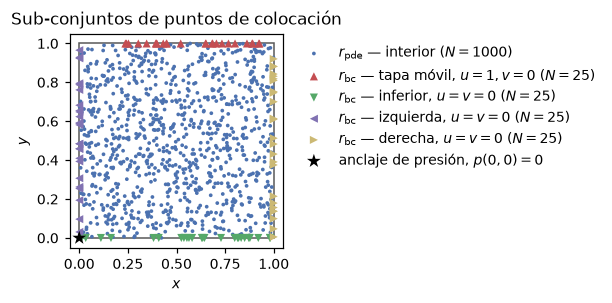

In [4]:
STYLE = {
    "pde":       dict(c="#4C72B0", s=6,  marker="o", label=r"$r_{\rm pde}$ — interior ($N=1000$)"),
    "bc_top":    dict(c="#C44E52", s=28, marker="^", label=r"$r_{\rm bc}$ — tapa móvil, $u=1,v=0$ ($N=25$)"),
    "bc_bottom": dict(c="#55A868", s=28, marker="v", label=r"$r_{\rm bc}$ — inferior, $u=v=0$ ($N=25$)"),
    "bc_left":   dict(c="#8172B2", s=28, marker="<", label=r"$r_{\rm bc}$ — izquierda, $u=v=0$ ($N=25$)"),
    "bc_right":  dict(c="#CCB974", s=28, marker=">", label=r"$r_{\rm bc}$ — derecha, $u=v=0$ ($N=25$)"),
    "anchor":    dict(c="k",       s=90, marker="*", label=r"anclaje de presión, $p(0,0)=0$"),
}

fig, ax = plt.subplots(figsize=(5.6, 5.6))
for name, sub in collocation.items():
    xy = sub["xy"].cpu().numpy()
    ax.scatter(xy[:, 0], xy[:, 1], zorder=3, edgecolors="none", **STYLE[name])
ax.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False, lw=1.0, ec="0.35", zorder=2))
ax.set(xlabel="$x$", ylabel="$y$", xlim=(-0.05, 1.05), ylim=(-0.05, 1.05), aspect="equal",
       title="Sub-conjuntos de puntos de colocación")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "01_puntos_colocacion.png", bbox_inches="tight")
plt.show()

---
# 2. Solución de referencia (*ground-truth*) y datos rotulados

La carpeta `Re-100/` contiene la solución MEF sobre una malla uniforme de cuadriláteros: `pressure.mat` (campo $p$)
y `velocity.mat` (campo $\boldsymbol{u}=[u,v]^T$). Ambos archivos comparten la misma nube de **20 201 nodos**, que
corresponde a una malla de $100\times100$ elementos: $101\times101 = 10\,201$ vértices más $100\times100=10\,000$
centros de elemento. La sub-malla de vértices (paso $h=0{,}01$) es una grilla estructurada y es la que se usa para
los mapas de campo y los perfiles; las métricas de error se computan sobre **los 20 201 nodos**, es decir sobre la
misma grilla de puntos empleada por la solución de referencia.

In [5]:
def load_reference(folder=DATA_DIR):
    """Carga la solucion MEF de referencia (nube de nodos dispersa)."""
    P = sio.loadmat(folder / "pressure.mat")
    V = sio.loadmat(folder / "velocity.mat")
    x, y = P["x"].ravel(), P["y"].ravel()
    assert np.allclose(x, V["x"].ravel()) and np.allclose(y, V["y"].ravel()), \
        "pressure.mat y velocity.mat no comparten la misma nube de nodos"
    return {"x": x, "y": y, "u": V["u"].ravel(), "v": V["v"].ravel(), "p": P["p"].ravel()}


def structured_grid(ref, h=0.01):
    """Extrae la sub-malla estructurada de vertices (paso h) como arrays 2D."""
    on_node = lambda a: np.abs(a / h - np.round(a / h)) < 1e-9
    m = on_node(ref["x"]) & on_node(ref["y"])
    ix = np.round(ref["x"][m] / h).astype(int)
    iy = np.round(ref["y"][m] / h).astype(int)
    nx, ny = ix.max() + 1, iy.max() + 1
    out = {"x": np.linspace(0, 1, nx), "y": np.linspace(0, 1, ny), "mask": m}
    for k in ("u", "v", "p"):
        A = np.full((ny, nx), np.nan)
        A[iy, ix] = ref[k][m]
        assert not np.isnan(A).any(), f"la sub-malla de vertices esta incompleta para {k}"
        out[k] = A
    return out


ref = load_reference()
grid = structured_grid(ref)

print(f"nodos de referencia : {ref['x'].size}")
print(f"sub-malla vértices  : {grid['y'].size} x {grid['x'].size} (h = 0.01)")
for k in ("u", "v", "p"):
    print(f"  {k}: min = {ref[k].min():+.4f}   max = {ref[k].max():+.4f}")
print(f"\np en el origen (anclaje MEF): {ref['p'][(ref['x'] == 0) & (ref['y'] == 0)][0]:.3e}")

nodos de referencia : 20201
sub-malla vértices  : 101 x 101 (h = 0.01)
  u: min = -0.2392   max = +1.0000
  v: min = -0.5246   max = +0.3038
  p: min = -4.6325   max = +5.7344

p en el origen (anclaje MEF): 0.000e+00


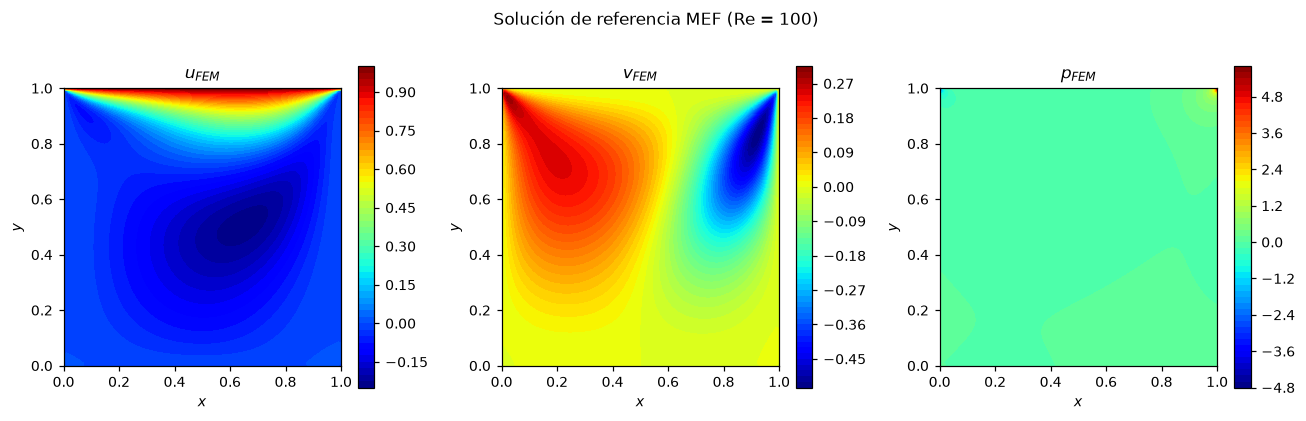

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, (k, ttl) in zip(axes, [("u", "$u_{FEM}$"), ("v", "$v_{FEM}$"), ("p", "$p_{FEM}$")]):
    im = ax.contourf(grid["x"], grid["y"], grid[k], levels=60, cmap="jet")
    fig.colorbar(im, ax=ax)
    ax.set(title=ttl, xlabel="$x$", ylabel="$y$", aspect="equal")
fig.suptitle("Solución de referencia MEF (Re = 100)", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_ground_truth.png", bbox_inches="tight")
plt.show()

## Consigna 3 — Dataset de datos rotulados ($N_{\rm data}=10$)

Se sortean 10 posiciones $(x,y)$ **en el interior** del dominio y se toman de la solución MEF las "mediciones"
de $p$, $u$ y $v$ en esos puntos. Se restringe el sorteo al interior para que representen mediciones útiles: sobre
las paredes los valores ya son conocidos por las condiciones de borde y no aportarían información nueva.

In [7]:
def build_labeled_dataset(ref, n=N_DATA, rng=rng, margin=0.02):
    """Toma n nodos interiores de la referencia MEF y arma pares (entrada, medicion)."""
    interior = np.where((ref["x"] > margin) & (ref["x"] < 1 - margin) &
                        (ref["y"] > margin) & (ref["y"] < 1 - margin))[0]
    idx = rng.choice(interior, size=n, replace=False)
    return {
        "xy": torch.tensor(np.stack([ref["x"][idx], ref["y"][idx]], axis=1), dtype=DTYPE),
        "uv": torch.tensor(np.stack([ref["u"][idx], ref["v"][idx]], axis=1), dtype=DTYPE),
        "p": torch.tensor(ref["p"][idx][:, None], dtype=DTYPE),
    }


data_ds = build_labeled_dataset(ref)

print(f"{'#':>3} {'x':>8} {'y':>8} | {'u_medido':>10} {'v_medido':>10} {'p_medido':>10}")
print("-" * 56)
for i, (xy, uv, p) in enumerate(zip(data_ds["xy"], data_ds["uv"], data_ds["p"])):
    print(f"{i:>3} {xy[0]:8.3f} {xy[1]:8.3f} | {uv[0]:10.5f} {uv[1]:10.5f} {p[0]:10.5f}")

  #        x        y |   u_medido   v_medido   p_medido
--------------------------------------------------------
  0    0.965    0.935 |   -0.04020   -0.47414    0.50055
  1    0.280    0.640 |   -0.06961    0.22674   -0.04486
  2    0.635    0.955 |    0.73328   -0.00237   -0.06696
  3    0.950    0.750 |   -0.04342   -0.36130    0.04348
  4    0.260    0.530 |   -0.09143    0.19005   -0.02761
  5    0.870    0.350 |   -0.04415   -0.08890    0.00110
  6    0.640    0.290 |   -0.14532   -0.05908    0.00103
  7    0.160    0.230 |   -0.03480    0.04300   -0.00081
  8    0.495    0.935 |    0.58024    0.02225   -0.06680
  9    0.385    0.835 |    0.11422    0.13838   -0.06132


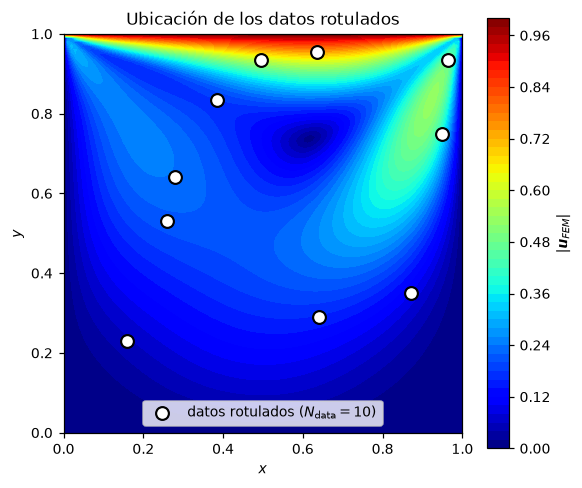

In [8]:
fig, ax = plt.subplots(figsize=(5.4, 4.6))
im = ax.contourf(grid["x"], grid["y"], np.hypot(grid["u"], grid["v"]), levels=60, cmap="jet")
fig.colorbar(im, ax=ax, label=r"$|\boldsymbol{u}_{FEM}|$")
xy = data_ds["xy"].numpy()
ax.scatter(xy[:, 0], xy[:, 1], s=70, marker="o", facecolor="w", edgecolor="k", lw=1.4,
           zorder=4, label=f"datos rotulados ($N_{{\\rm data}}={N_DATA}$)")
ax.set(title="Ubicación de los datos rotulados", xlabel="$x$", ylabel="$y$", aspect="equal")
ax.legend(loc="lower center", frameon=True)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_datos_rotulados.png", bbox_inches="tight")
plt.show()

### ¿Qué sugiere la estructura de este dataset complementario respecto de los sub-conjuntos de colocación?

La diferencia es **qué representa el *label*** y, en consecuencia, qué forma tiene la estructura de datos:

1. **Los sub-conjuntos de colocación no tienen *labels* medidos.** Para el sub-conjunto `pde` el "label" es el
   valor deseado del residuo, que es **idénticamente cero** y por lo tanto no hace falta almacenarlo: alcanza con
   las coordenadas $(x,y)$, porque el objetivo está codificado en el operador diferencial, no en los datos.
   (Las implementaciones de referencia de la cátedra sí lo almacenan, como un tensor `y_dom = torch.zeros(...)`.
   No es una necesidad conceptual sino de interfaz: al tener todos los sub-conjuntos la forma `TensorDataset(X, y)`,
   el mismo `nn.MSELoss()` sirve para todos los términos sin ramificar el código. Es la misma decisión de diseño
   que se discute al final de esta sección.) Para los
   sub-conjuntos `bc_*` el *label* existe pero es un **valor prescripto por el enunciado** ($u=1,v=0$ o $u=v=0$),
   constante dentro de cada pared y deducible de la geometría; se guarda por comodidad, no porque provenga de una
   medición.
2. **El dataset de datos rotulados sí necesita un tensor de salidas por punto.** Su estructura es la de un dataset
   de aprendizaje supervisado clásico: pares $\big((x_i,y_i),\ (u_i,v_i,p_i)\big)$, con un *label* distinto e
   independiente para cada muestra, que **no puede derivarse** ni de la geometría ni de la física — proviene de una
   fuente externa (mediciones o, aquí, la solución MEF).
3. **Consecuencias prácticas:** (i) es el único sub-conjunto cuyo tamaño no se puede aumentar libremente: los
   puntos de colocación se sortean a voluntad, mientras que las mediciones son un recurso escaso y fijo;
   (ii) es el único que puede traer **ruido** en el *label*, lo que impacta en cómo se pondera su término de pérdida
   (no tiene sentido llevar $\mathcal{L}_{\rm data}$ por debajo del nivel de ruido de las mediciones);
   (iii) al rotular también $p$, aporta información sobre una variable que las condiciones de borde no fijan en
   ningún punto, con lo cual vuelve innecesario el anclaje artificial $p(0,0)=0$;
   (iv) es la estructura que habilita el **problema inverso**: si $\mathrm{Re}$ pasa a ser un parámetro entrenable,
   son estos *labels* — y sólo ellos — los que contienen la información para identificarlo.

En términos de implementación, esto sugiere una estructura común `{xy, target}` para todos los sub-conjuntos, en la
que `target` es opcional (ausente en `pde`), fijo por construcción en `bc_*` y un tensor de datos externos en
`data`. Eso es exactamente lo que se implementó en `build_collocation()` y `build_labeled_dataset()`.

### La coincidencia formal esconde una diferencia conceptual

Hay un punto más profundo, y es el que explica por qué conviene mantener los dos datasets separados aunque su
término de pérdida se escriba igual. Ambos términos tienen la misma forma —promedio de cuadrados—

$$\mathcal{L}_{\rm pde} = \frac{1}{N_{\rm pde}}\sum_i r_{\rm pde}(\boldsymbol{x}_i)^2
\qquad\qquad
\mathcal{L}_{\rm data} = \frac{1}{N_{\rm data}}\sum_i \big(\hat{\boldsymbol{q}}(\boldsymbol{x}_i) -
\boldsymbol{q}_i\big)^2$$

pero **no son el mismo objeto matemático**:

| | $\mathcal{L}_{\rm data}$ (datos rotulados) | $\mathcal{L}_{\rm pde}$, $\mathcal{L}_{\rm bc}$ (colocación) |
|---|---|---|
| Qué estima | el **riesgo poblacional**: la esperanza del error bajo la distribución que generó los datos | una **integral determinista**: la norma $L^2$ del residuo sobre $\Omega$ |
| Tipo de estimador | estadístico (MSE), insesgado bajo un modelo generativo gaussiano | numérico (Monte Carlo), insesgado respecto de la integral continua |
| Qué se gana con más muestras | mejor generalización a datos nuevos | menor error de cuadratura |
| Hay proceso estocástico detrás | sí: ruido de medición | **no**: el residuo es determinista, debería ser exactamente cero |

La consecuencia práctica: minimizar $\mathcal{L}_{\rm data}$ **no** tiene interpretación como estimación de máxima
verosimilitud en el caso de los residuos, porque no hay ningún proceso aleatorio que los genere. Por eso los
puntos de colocación se pueden sortear a voluntad (cambiar la muestra sólo cambia la precisión de una cuadratura)
mientras que los datos rotulados son un recurso fijo y ruidoso, y por eso tiene sentido llevar $\mathcal{L}_{\rm pde}$
tan cerca de cero como se pueda pero **no** $\mathcal{L}_{\rm data}$, que no debe bajar del nivel de ruido de las
mediciones.

## Consigna 4 — ¿Debería el sub-conjunto de la PDE contener puntos sobre las fronteras físicas?

**No: conviene restringirlo al interior abierto de $\Omega$.** Razones, de más a menos importante:

1. **Las esquinas de la tapa son singulares.** En $(0,1)$ y $(1,1)$ la condición de borde es discontinua ($u=1$ por
   arriba, $u=0$ por el costado). La solución exacta tiene allí presión y vorticidad no acotadas ($p\sim\log r$),
   de modo que el residuo de la PDE evaluado en un entorno de la esquina crece sin control. Como $\mathcal{L}_{\rm pde}$
   es un promedio de cuadrados, unos pocos puntos con residuo enorme dominan el gradiente y degradan el ajuste en
   todo el resto del dominio. Éste es el argumento decisivo en este problema.
2. **Redundancia y conflicto entre términos.** Sobre la frontera ya actúa $\mathcal{L}_{\rm bc}$, que impone
   valores exactos. Agregar allí el residuo de la PDE superpone dos objetivos sobre los mismos puntos, con pesos
   $\lambda_{\rm pde}$ y $\lambda_{\rm bc}$ que compiten y hacen más difícil balancear la pérdida.
3. **El muestreo uniforme del interior ya cubre la frontera en el límite.** La frontera tiene medida nula: al
   sortear puntos uniformemente en $\Omega$ aparecen puntos arbitrariamente cerca de la pared, y la continuidad de
   la red (y de sus derivadas) propaga el cumplimiento de la PDE hasta el borde. No hace falta evaluarla *sobre* la
   frontera para que se satisfaga allí.

**Matices que conviene registrar.** La PDE sí es válida sobre la frontera (excepto en las dos esquinas singulares),
y hay un argumento a favor de muestrear *cerca* de ella: en la cavidad a Re = 100 los gradientes más fuertes están
en las capas límite junto a las paredes, y el muestreo uniforme las cubre pobremente. La respuesta correcta a esa
necesidad no es colocar puntos *sobre* la frontera, sino **densificar el muestreo en la banda adyacente** —
muestreo estratificado, sesgado hacia la pared o adaptativo por residuo. Esto se retoma más adelante en el trabajo.

**Qué hacen las implementaciones de referencia de la cátedra.** Vale contrastar, porque hacen lo contrario. Tanto
`heat_equation.ipynb` como `burgers_equation.ipynb` concatenan los puntos de borde e iniciales dentro del
sub-conjunto del residuo:

```python
X_dom = torch.cat([X_dom, X_bc_l, X_bc_r, X_ic], axis=0)
y_dom = torch.cat([y_dom, y_bc_l, y_bc_r, y_ic], axis=0)
```

es decir, evalúan la PDE **también sobre las fronteras**, y en paralelo arman los datasets de BC/IC con los valores
prescriptos. Al repetirse igual en ambas notebooks, es una decisión deliberada y no un descuido.

La discrepancia con la conclusión de arriba no es casual: **depende de la regularidad de la condición de borde del
problema**. En la ecuación del calor y en Burgers las condiciones de borde son continuas y compatibles con la
condición inicial, de modo que la solución es suave hasta el borde y el residuo evaluado allí está acotado y aporta
información útil — más puntos de colocación gratis, en la zona donde además hay que satisfacer las BC. En la cavidad
la situación cambia por completo: la condición de la tapa es **discontinua en las dos esquinas superiores**, la
solución exacta no está acotada allí y el residuo evaluado en esos puntos contamina un promedio de cuadrados.

La conclusión, entonces, no es que la práctica de la cátedra sea incorrecta, sino que **la respuesta a esta consigna
depende del problema**, y la cavidad cae del lado en que conviene excluir la frontera. Con la salvedad de que si el
perfil de la tapa se regularizara —por ejemplo con $u(x,1)=1-\cosh(C(x-1/2))/\cosh(C/2)$, práctica habitual en la
literatura de PINNs para este caso— desaparecería la singularidad y con ella la objeción principal, y incluir los
puntos de la frontera pasaría a ser tan razonable como en los ejemplos.

Conclusión: `sample_interior()` sortea en $(0,1)^2$ abierto y ningún punto del sub-conjunto `pde` cae sobre las
fronteras físicas.

---
# 3. Implementación del esquema *vanilla* PINN

## Arquitectura

- **Entradas: 2** — las variables independientes del problema, $(x,y)$. El problema es estacionario, con lo cual no
  hay entrada temporal, y bidimensional.
- **Salidas: 3** — las variables dependientes a modelar, $(\hat u, \hat v, \hat p)$. Se usa una única red con tres
  salidas (en lugar de tres redes independientes) porque los tres campos están fuertemente acoplados por las
  ecuaciones y comparten la misma estructura espacial; el tronco compartido actúa como representación común.
- **Profundidad y ancho: 5 capas ocultas de 64 neuronas.** Compromiso habitual para Navier-Stokes 2D estacionario:
  suficiente capacidad para la recirculación principal y los vórtices secundarios, y suficientemente chica para que
  el costo de la doble diferenciación se mantenga acotado.
- **Activación: $\tanh$.** Es $C^\infty$, condición necesaria para que las derivadas segundas obtenidas por
  autodiferenciación existan y sean continuas. Con ReLU la derivada segunda sería nula en casi todo punto y el
  término viscoso $\nabla^2\boldsymbol{u}$ quedaría idénticamente cero. La capa de salida es **lineal**, para no
  restringir el rango de $\hat p$ (que es negativo en buena parte del dominio).
- **Normalización de la entrada.** Se mapea $\Omega=[0,1]^2 \to [-1,1]^2$ antes de la primera capa, que es la zona
  de mayor gradiente de $\tanh$. Con entradas en $[0,1]$ la red arranca sesgada hacia la rama positiva de la
  activación y converge más lento.
- **Inicialización: Xavier (Glorot) normal**, con sesgos en cero. Es la adecuada para activaciones simétricas como
  $\tanh$: mantiene la varianza de las activaciones y de los gradientes a lo largo de la profundidad, lo cual es
  crítico acá porque el gradiente atraviesa la red **dos veces** (una por la doble diferenciación de los residuos y
  otra por la retropropagación).

In [10]:
class PINN(nn.Module):
    """Red densa (fully-connected) con normalizacion de entrada al hipercubo [-1,1]."""

    def __init__(self, layers, lb=(0.0, 0.0), ub=(1.0, 1.0), activation=nn.Tanh):
        super().__init__()
        self.register_buffer("lb", torch.tensor(lb, dtype=DTYPE))
        self.register_buffer("ub", torch.tensor(ub, dtype=DTYPE))
        mods = []
        for i in range(len(layers) - 1):
            mods.append(nn.Linear(layers[i], layers[i + 1]))
            if i < len(layers) - 2:            # la ultima capa es lineal
                mods.append(activation())
        self.net = nn.Sequential(*mods)
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(m):
        """Inicializacion de Xavier (Glorot) normal, adecuada para tanh."""
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight, gain=nn.init.calculate_gain("tanh"))
            nn.init.zeros_(m.bias)

    def forward(self, xy):
        z = 2.0 * (xy - self.lb) / (self.ub - self.lb) - 1.0
        return self.net(z)


LAYERS = [2] + [64] * 5 + [3]
print(PINN(LAYERS))
print(f"\nparámetros entrenables: {sum(p.numel() for p in PINN(LAYERS).parameters()):,}")

PINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=64, bias=True)
    (9): Tanh()
    (10): Linear(in_features=64, out_features=3, bias=True)
  )
)

parámetros entrenables: 17,027


## Cómputo de los residuos por autodiferenciación

El punto delicado del esquema. Las derivadas de $\hat u,\hat v,\hat p$ respecto de $x$ e $y$ **no** se aproximan por
diferencias finitas: se obtienen con `torch.autograd.grad` sobre el grafo de cómputo de la red, lo que las vuelve
exactas a precisión de máquina.

Detalles de implementación que importan:

- `create_graph=True` en cada llamada: sin él, la primera derivada no queda registrada en el grafo y no se podrían
  calcular ni las derivadas segundas ni el gradiente de la pérdida respecto de los pesos.
- Se deriva respecto del tensor de entrada completo `xy`, de modo que cada llamada devuelve un tensor de dos
  columnas: `[·]_x` en la columna 0 y `[·]_y` en la columna 1. Para el laplaciano se toma $\partial_x$ de $u_x$
  (columna 0) y $\partial_y$ de $u_y$ (columna 1); las cruzadas se descartan.
- `xy` debe tener `requires_grad_(True)` **antes** del forward.

Residuos, con $\mathrm{Re}=100$:

$$r_x = \hat u\,\hat u_x + \hat v\,\hat u_y + \hat p_x - \tfrac{1}{\mathrm{Re}}(\hat u_{xx}+\hat u_{yy}),\qquad
  r_y = \hat u\,\hat v_x + \hat v\,\hat v_y + \hat p_y - \tfrac{1}{\mathrm{Re}}(\hat v_{xx}+\hat v_{yy}),\qquad
  r_c = \hat u_x + \hat v_y$$

In [11]:
def d(f, x):
    """Gradiente de f respecto de x, manteniendo el grafo para derivadas de orden superior."""
    return torch.autograd.grad(f, x, grad_outputs=torch.ones_like(f), create_graph=True)[0]


def pde_residuals(model, xy, Re=RE):
    """Residuos de Navier-Stokes estacionario incompresible: (r_x, r_y, r_c)."""
    xy = xy.clone().requires_grad_(True)
    out = model(xy)
    u, v, p = out[:, 0:1], out[:, 1:2], out[:, 2:3]

    du, dv, dp = d(u, xy), d(v, xy), d(p, xy)     # columna 0 -> d/dx, columna 1 -> d/dy
    u_x, u_y = du[:, 0:1], du[:, 1:2]
    v_x, v_y = dv[:, 0:1], dv[:, 1:2]
    p_x, p_y = dp[:, 0:1], dp[:, 1:2]

    u_xx = d(u_x, xy)[:, 0:1]
    u_yy = d(u_y, xy)[:, 1:2]
    v_xx = d(v_x, xy)[:, 0:1]
    v_yy = d(v_y, xy)[:, 1:2]

    r_x = u * u_x + v * u_y + p_x - (u_xx + u_yy) / Re     # cantidad de movimiento en x
    r_y = u * v_x + v * v_y + p_y - (v_xx + v_yy) / Re     # cantidad de movimiento en y
    r_c = u_x + v_y                                        # continuidad
    return r_x, r_y, r_c


# ---- verificación del esquema de autodiferenciación contra diferencias finitas -------------
# Chequeo de sanidad: u_xx por autodiff debe coincidir con el cociente incremental centrado.
#
# No alcanza con comparar contra diferencias finitas para un unico h: el esquema centrado
# tiene un error de truncamiento propio O(h^2), y a h grande ese error es del mismo orden que
# la magnitud de u_xx, con lo cual una discrepancia grande no distingue "autodiff mal" de
# "diferencias finitas imprecisas". La verificacion correcta es comprobar el ORDEN: si el
# autodiff es exacto, la discrepancia debe caer como h^2 (factor 100 por cada decada de h).
#
# El chequeo va en float64 y sobre CPU: la diferencia segunda divide un error de redondeo
# O(eps) por h^2, de modo que en float32 (eps ~ 1e-7) el ruido de cancelacion domina y el
# test mediria la precision del punto flotante en vez de las derivadas.
check_model = PINN(LAYERS).double()
xy_chk = torch.rand(5, 2, dtype=torch.float64)

xy_ad = xy_chk.clone().requires_grad_(True)
u_xx_ad = d(d(check_model(xy_ad)[:, 0:1], xy_ad)[:, 0:1], xy_ad)[:, 0]

print("Verificación de u_xx: autodiff vs. diferencias finitas centradas (float64)\n")
print(f"{'h':>8} {'error rel. en norma':>22} {'factor vs. h anterior':>24}")
print("-" * 56)
prev = None
for h in (1e-1, 1e-2, 1e-3, 1e-4):
    with torch.no_grad():
        e_x = torch.tensor([[h, 0.0]], dtype=torch.float64)
        u_xx_fd = (check_model(xy_chk + e_x)[:, 0]
                   - 2 * check_model(xy_chk)[:, 0]
                   + check_model(xy_chk - e_x)[:, 0]) / h ** 2
    err = ((u_xx_ad - u_xx_fd).norm() / u_xx_ad.norm()).item()
    print(f"{h:>8.0e} {err:>22.3e} {'—' if prev is None else f'{prev / err:>21.1f}x'}")
    prev = err
print("\nLa discrepancia cae ~100x por década de h: convergencia de orden 2, la del esquema "
      "de\ndiferencias finitas. El cómputo de derivadas por autodiferenciación es exacto.")

Verificación de u_xx: autodiff vs. diferencias finitas centradas (float64)

       h    error rel. en norma    factor vs. h anterior
--------------------------------------------------------
   1e-01              2.633e-01 —
   1e-02              3.425e-03                  76.9x
   1e-03              3.435e-05                  99.7x
   1e-04              3.408e-07                 100.8x

La discrepancia cae ~100x por década de h: convergencia de orden 2, la del esquema de
diferencias finitas. El cómputo de derivadas por autodiferenciación es exacto.


## Función de pérdida, optimizador e hiperparámetros

$$\mathcal{L} = \lambda_{\rm pde}\underbrace{\overline{(r_x^2+r_y^2+r_c^2)}}_{\mathcal{L}_{\rm pde}}
 + \lambda_{\rm bc}\underbrace{\overline{\big((\hat u-u^\ast)^2+(\hat v-v^\ast)^2\big)}}_{\mathcal{L}_{\rm bc}}
 + \lambda_{p}\underbrace{(\hat p(0,0)-0)^2}_{\mathcal{L}_{p}}$$

**Pesos: $\lambda_{\rm pde}=1$, $\lambda_{\rm bc}=10$, $\lambda_{p}=1$.** Las condiciones de borde se ponderan por
encima del residuo porque son las que hacen único al problema: son la única fuente de información sobre *cuál* de
las infinitas soluciones de la PDE se busca, y son además el motor del flujo (sin la tapa, $\boldsymbol{u}\equiv 0$,
$p\equiv$ cte. es solución exacta de la PDE con residuo nulo — un mínimo global de $\mathcal{L}_{\rm pde}$ y una
trampa clásica del esquema *vanilla*). Con $\lambda_{\rm bc}=1$ el entrenamiento tiende a quedar atrapado cerca de
esa solución trivial durante muchas épocas.

**Optimizador: Adam**, $\mathrm{lr}=10^{-3}$ con decaimiento por pasos (×0,5 cada 5000 épocas).

**`weight_decay = 0`.** 

**Épocas: 20 000, a lote completo**

In [ ]:
WEIGHTS = {"pde": 1.0, "bc": 10.0, "anchor": 1.0}
EPOCHS = 20_000
LR = 1e-3
LR_STEP, LR_GAMMA = 5_000, 0.5
LOG_EVERY = 500


def pack_bc(ds):
    """Concatena las cuatro paredes y el anclaje en un unico tensor de entrada.

    Con tensores tan chicos (25 puntos por pared) el costo dominante no es
    aritmetico sino el *despacho* de kernels: cinco forwards separados lanzan
    cinco veces la misma cadena de nucleos para hacer un trabajo despreciable.
    Se evalua todo de una y se recuperan despues las contribuciones por pared
    rebanando el resultado, de modo que el log desagregado no se pierde.
    """
    keys = sorted(k for k in ds if k.startswith("bc_"))
    bounds = np.cumsum([0] + [len(ds[k]["xy"]) for k in keys])
    return {
        "xy": torch.cat([ds[k]["xy"] for k in keys] + [ds["anchor"]["xy"]]),
        "uv": torch.cat([ds[k]["uv"] for k in keys]),
        "n_bc": int(bounds[-1]),
        "keys": keys,
        "bounds": bounds,
    }


def compute_losses(model, ds, bc, Re=RE):
    """Devuelve las contribuciones de cada sub-conjunto a la funcion de perdida."""
    r_x, r_y, r_c = pde_residuals(model, ds["pde"]["xy"], Re)
    L = {
        "pde_x": r_x.pow(2).mean(),
        "pde_y": r_y.pow(2).mean(),
        "pde_c": r_c.pow(2).mean(),
    }
    out = model(bc["xy"])                                  
    se = (out[:bc["n_bc"], 0:2] - bc["uv"]).pow(2).mean(dim=1)
    for k, a, b in zip(bc["keys"], bc["bounds"][:-1], bc["bounds"][1:]):
        L[k] = se[a:b].mean()
    L["anchor"] = (out[bc["n_bc"]:, 2:3] - ds["anchor"]["p"]).pow(2).mean()
    return L


def total_loss(L, weights=WEIGHTS):
    """Suma ponderada de las contribuciones de cada termino."""
    pde = L["pde_x"] + L["pde_y"] + L["pde_c"]
    bc = sum(v for k, v in L.items() if k.startswith("bc_")) / 4.0
    return weights["pde"] * pde + weights["bc"] * bc + weights["anchor"] * L["anchor"], pde, bc


def train(model, ds, epochs=EPOCHS, lr=LR, weights=WEIGHTS, log_every=LOG_EVERY, tag=""):
    """Loop de entrenamiento a lote completo con Adam y decaimiento del learning rate."""
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0.0)
    sched = torch.optim.lr_scheduler.StepLR(opt, step_size=LR_STEP, gamma=LR_GAMMA)
    bc_pack = pack_bc(ds)
    hist = {k: [] for k in ["epoch", "total", "pde", "bc", "anchor",
                            "pde_x", "pde_y", "pde_c", "lr"]}
    t0 = t_prev = time.time()
    print(f"{'época':>7} {'total':>11} {'L_pde':>11} {'L_bc':>11} {'L_anchor':>11} "
          f"{'lr':>9} {'t[s]':>8} {'it/s':>7}")
    for ep in range(epochs + 1):
        L = compute_losses(model, ds, bc_pack)
        loss, pde, bc = total_loss(L, weights)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()
        sched.step()

        if ep % log_every == 0 or ep == epochs:
            now = time.time()
            rate = log_every / (now - t_prev) if ep else float("nan")
            t_prev = now
            for k, val in [("epoch", ep), ("total", loss.item()), ("pde", pde.item()),
                           ("bc", bc.item()), ("anchor", L["anchor"].item()),
                           ("pde_x", L["pde_x"].item()), ("pde_y", L["pde_y"].item()),
                           ("pde_c", L["pde_c"].item()), ("lr", sched.get_last_lr()[0])]:
                hist[k].append(val)
            print(f"{ep:>7d} {loss.item():>11.4e} {pde.item():>11.4e} {bc.item():>11.4e} "
                  f"{L['anchor'].item():>11.4e} {sched.get_last_lr()[0]:>9.2e} "
                  f"{now - t0:>8.1f} {rate:>7.1f}", flush=True)
    print(f"\nentrenamiento{' ' + tag if tag else ''} finalizado en {time.time() - t0:.1f} s")
    return {k: np.array(v) for k, v in hist.items()}

## Consigna 6 — Entrenamiento (sin datos rotulados)

El modelo se entrena **únicamente** con los residuos de la PDE, las condiciones de borde y el anclaje de presión.
El dataset `data_ds` construido en la consigna 3 no interviene.

In [32]:
torch.manual_seed(SEED)
model = PINN(LAYERS).to(DEVICE)
ds = to_device(collocation)

hist = train(model, ds, tag="base")

  época       total       L_pde        L_bc    L_anchor        lr     t[s]    it/s
      0  1.5344e+02  1.2795e+02  1.7522e+00  7.9667e+00  1.00e-03      0.0     nan
    500  1.2923e-01  3.6379e-02  9.2836e-03  1.0863e-05  1.00e-03      5.5    92.0
   1000  7.9982e-02  2.0924e-02  5.9058e-03  1.2826e-06  1.00e-03     10.9    92.4
   1500  5.4591e-02  1.4377e-02  4.0214e-03  2.7785e-07  1.00e-03     16.4    91.3
   2000  3.7619e-02  1.0516e-02  2.7103e-03  9.0474e-09  1.00e-03     21.8    92.0
   2500  2.9375e-02  1.0327e-02  1.9047e-03  1.4226e-06  1.00e-03     27.4    89.8
   3000  1.9765e-02  6.3016e-03  1.3463e-03  1.4017e-07  1.00e-03     32.9    90.4
   3500  1.5688e-02  5.0467e-03  1.0641e-03  8.9080e-08  1.00e-03     38.6    87.7
   4000  1.3566e-02  4.4313e-03  9.1348e-04  5.9304e-08  1.00e-03     44.2    88.8
   4500  1.3127e-02  4.5697e-03  8.5548e-04  2.8457e-06  1.00e-03     49.9    87.7
   5000  1.2298e-02  4.5902e-03  7.6165e-04  9.1148e-05  5.00e-04     55.6    88.7
   5

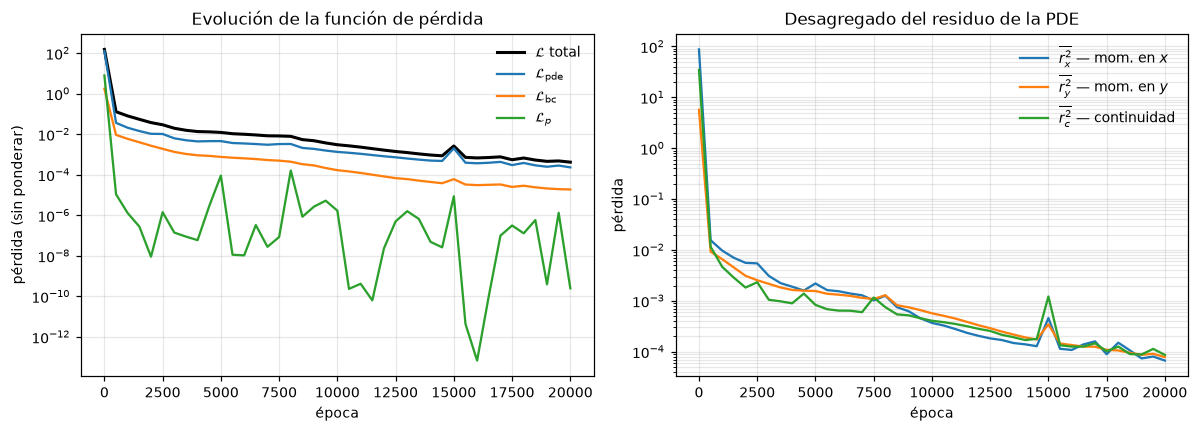

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.semilogy(hist["epoch"], hist["total"], "k", lw=2, label=r"$\mathcal{L}$ total")
ax.semilogy(hist["epoch"], hist["pde"], label=r"$\mathcal{L}_{\rm pde}$")
ax.semilogy(hist["epoch"], hist["bc"], label=r"$\mathcal{L}_{\rm bc}$")
ax.semilogy(hist["epoch"], hist["anchor"], label=r"$\mathcal{L}_{p}$")
ax.set(xlabel="época", ylabel="pérdida (sin ponderar)", title="Evolución de la función de pérdida")
ax.legend(frameon=False)
ax.grid(alpha=0.3, which="both")

ax = axes[1]
ax.semilogy(hist["epoch"], hist["pde_x"], label=r"$\overline{r_x^2}$ — mom. en $x$")
ax.semilogy(hist["epoch"], hist["pde_y"], label=r"$\overline{r_y^2}$ — mom. en $y$")
ax.semilogy(hist["epoch"], hist["pde_c"], label=r"$\overline{r_c^2}$ — continuidad")
ax.set(xlabel="época", ylabel="pérdida", title="Desagregado del residuo de la PDE")
ax.legend(frameon=False)
ax.grid(alpha=0.3, which="both")

fig.tight_layout()
fig.savefig(FIG_DIR / "04_perdidas.png", bbox_inches="tight")
plt.show()

---
# 4. Evaluación del desempeño

## Consigna 7 — Norma-2 del error

Se predice sobre **los mismos 20 201 nodos** de la solución de referencia y se reporta, para cada campo
$f\in\{u,v,p\}$:

$$\|e_f\|_2 = \Big(\sum_i (\hat f_i - f_i)^2\Big)^{1/2}, \qquad
  \varepsilon_f = \frac{\|e_f\|_2}{\|f\|_2}\ (\text{relativa}), \qquad
  \mathrm{RMSE}_f = \frac{\|e_f\|_2}{\sqrt{N}}$$

La norma-2 absoluta depende de $N$; se agregan la relativa y el RMSE para poder interpretarla y comparar entre
campos de magnitudes distintas.

In [15]:
@torch.no_grad()
def predict(model, x, y, batch=50_000):
    """Evalua la red en una nube de puntos y devuelve (u, v, p) como arrays de numpy."""
    model.eval()
    xy = torch.tensor(np.stack([x, y], axis=1), dtype=DTYPE, device=DEVICE)
    out = torch.cat([model(xy[i:i + batch]) for i in range(0, len(xy), batch)]).cpu().numpy()
    return out[:, 0], out[:, 1], out[:, 2]


CORNER_R = 0.05   # radio de exclusion alrededor de las esquinas singulares de la tapa


def away_from_corners(ref, r=CORNER_R):
    """Mascara que excluye los entornos de las dos esquinas singulares (0,1) y (1,1)."""
    d0 = np.hypot(ref["x"] - 0.0, ref["y"] - 1.0)
    d1 = np.hypot(ref["x"] - 1.0, ref["y"] - 1.0)
    return (d0 > r) & (d1 > r)


def _stats(e, f):
    return {"l2": np.linalg.norm(e), "rel": np.linalg.norm(e) / np.linalg.norm(f),
            "rmse": np.linalg.norm(e) / np.sqrt(e.size), "max": np.abs(e).max()}


def error_metrics(model, ref, label=""):
    """Norma-2 del error (absoluta, relativa) y metricas auxiliares, por campo.

    Se reporta sobre todos los nodos y, por separado, sobre el subconjunto que
    excluye las esquinas singulares de la tapa: alli la solucion exacta no es
    acotada y ninguna red suave puede representarla, de modo que el error en esa
    zona informa sobre la regularidad del problema mas que sobre el modelo.
    """
    pred = dict(zip(("u", "v", "p"), predict(model, ref["x"], ref["y"])))
    m = away_from_corners(ref)

    rows, rows_in = {}, {}
    for k in ("u", "v", "p"):
        e = pred[k] - ref[k]
        rows[k] = _stats(e, ref[k])
        rows_in[k] = _stats(e[m], ref[k][m])
    # diagnostico: error de p una vez removido el desplazamiento constante optimo
    ep = pred["p"] - ref["p"]
    rows["p (sin offset)"] = _stats(ep - ep.mean(), ref["p"] - ref["p"].mean())
    rows_in["p (sin offset)"] = _stats(ep[m] - ep[m].mean(), ref["p"][m] - ref["p"][m].mean())

    head = f"{'campo':<16} {'||e||_2':>12} {'rel. ||e||/||f||':>18} {'RMSE':>12} {'|e|_max':>12}"
    for title, tbl, n in [
        (f"todos los nodos ({ref['x'].size})", rows, ref["x"].size),
        (f"excluyendo esquinas singulares, r < {CORNER_R} ({m.sum()} nodos)", rows_in, m.sum()),
    ]:
        print(f"\nError sobre {title}{' — ' + label if label else ''}\n")
        print(head)
        print("-" * 74)
        for k, r in tbl.items():
            print(f"{k:<16} {r['l2']:>12.4e} {r['rel']:>17.2%} {r['rmse']:>12.4e} {r['max']:>12.4e}")
    return rows, rows_in, pred


In [ ]:
metrics, metrics_in, pred = error_metrics(model, ref, "modelo base")
print(f"\ndesplazamiento medio de la presión: {(pred['p'] - ref['p']).mean():+.4e}")


Error sobre todos los nodos (20201) — modelo base

campo                 ||e||_2   rel. ||e||/||f||         RMSE      |e|_max
--------------------------------------------------------------------------
u                  6.5522e+00            21.07%   4.6100e-02   9.4961e-01
v                  7.6150e+00            36.15%   5.3578e-02   4.6764e-01
p                  1.0466e+01            69.98%   7.3637e-02   5.2678e+00
p (sin offset)     1.0381e+01            70.15%   7.3040e-02   5.2771e+00

Error sobre excluyendo esquinas singulares, r < 0.05 (20116 nodos) — modelo base

campo                 ||e||_2   rel. ||e||/||f||         RMSE      |e|_max
--------------------------------------------------------------------------
u                  5.5970e+00            18.15%   3.9463e-02   6.1593e-01
v                  7.2390e+00            34.51%   5.1039e-02   3.9183e-01
p                  3.2067e+00            36.62%   2.2609e-02   3.1657e-01
p (sin offset)     2.8846e+00            34.17%

## Consigna 8 — Error absoluto

Mapas de $|\hat f - f_{\rm FEM}|$ sobre la misma grilla, junto a los campos predicho y de referencia para
poder leerlos en contexto.

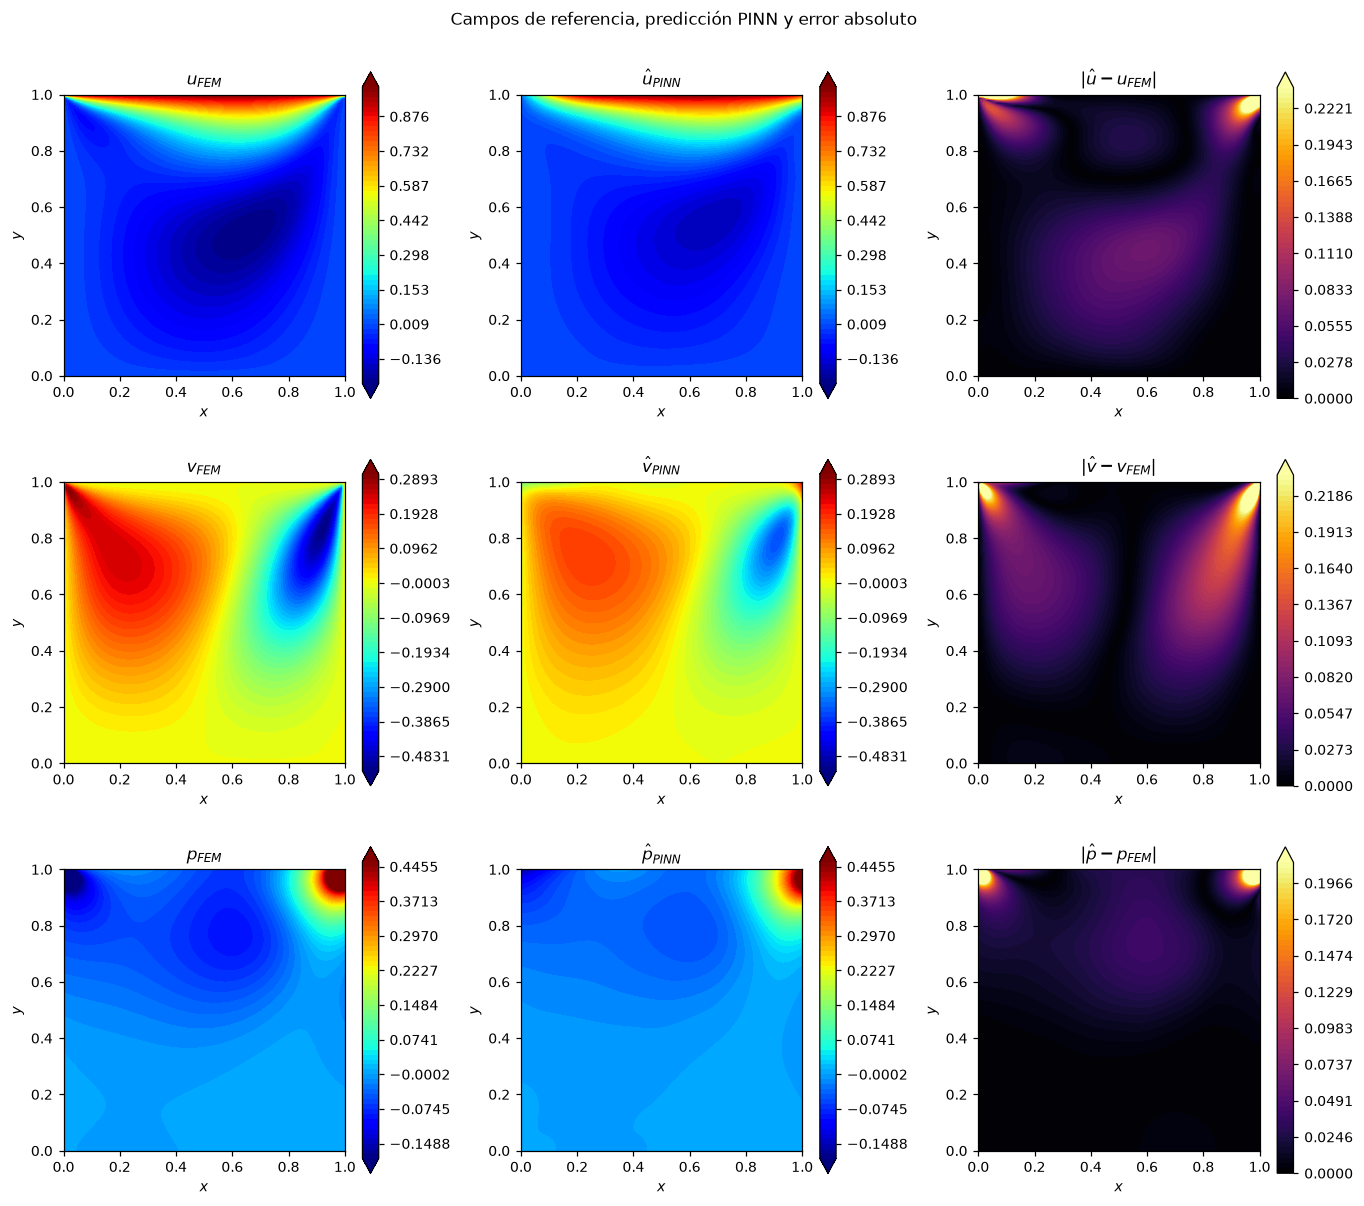

In [35]:
def field_comparison(model, grid, fname, title=""):
    """Fila por campo: referencia MEF, prediccion PINN y error absoluto."""
    X, Y = np.meshgrid(grid["x"], grid["y"])
    pu, pv, pp = predict(model, X.ravel(), Y.ravel())
    P = {"u": pu.reshape(X.shape), "v": pv.reshape(X.shape), "p": pp.reshape(X.shape)}

    fig, axes = plt.subplots(3, 3, figsize=(12.5, 11))
    for row, k in enumerate(("u", "v", "p")):
        ref_f, pred_f = grid[k], P[k]
        err = np.abs(pred_f - ref_f)
        # Niveles explicitos y COMPARTIDOS entre referencia y prediccion: con
        # `levels=<int>` matplotlib deriva los niveles de cada array y las dos
        # columnas quedarian en escalas distintas, visualmente incomparables.
        # Para p se usan percentiles robustos porque las esquinas singulares
        # saturan el rango (p va de -4.6 a 5.7 en dos puntos aislados).
        lo, hi = np.percentile(ref_f, [0.5, 99.5]) if k == "p" else (ref_f.min(), ref_f.max())
        lv = np.linspace(lo, hi, 61)
        lv_err = np.linspace(0, np.percentile(err, 99.5), 61)
        for col, (F, ttl, kw) in enumerate([
            (ref_f, f"${k}_{{FEM}}$", dict(cmap="jet", levels=lv, extend="both")),
            (pred_f, rf"$\hat{{{k}}}_{{PINN}}$", dict(cmap="jet", levels=lv, extend="both")),
            (err, rf"$|\hat{{{k}}} - {k}_{{FEM}}|$", dict(cmap="inferno", levels=lv_err, extend="max")),
        ]):
            ax = axes[row, col]
            im = ax.contourf(grid["x"], grid["y"], F, **kw)
            fig.colorbar(im, ax=ax)
            ax.set(title=ttl, xlabel="$x$", ylabel="$y$", aspect="equal")
    if title:
        fig.suptitle(title, y=1.0)
    fig.tight_layout()
    fig.savefig(FIG_DIR / fname, bbox_inches="tight")
    plt.show()
    return P


P_base = field_comparison(model, grid, "05_campos_error.png",
                          "Campos de referencia, predicción PINN y error absoluto")

## Consigna 9 — Perfiles sobre $x=0{,}5$ e $y=0{,}5$

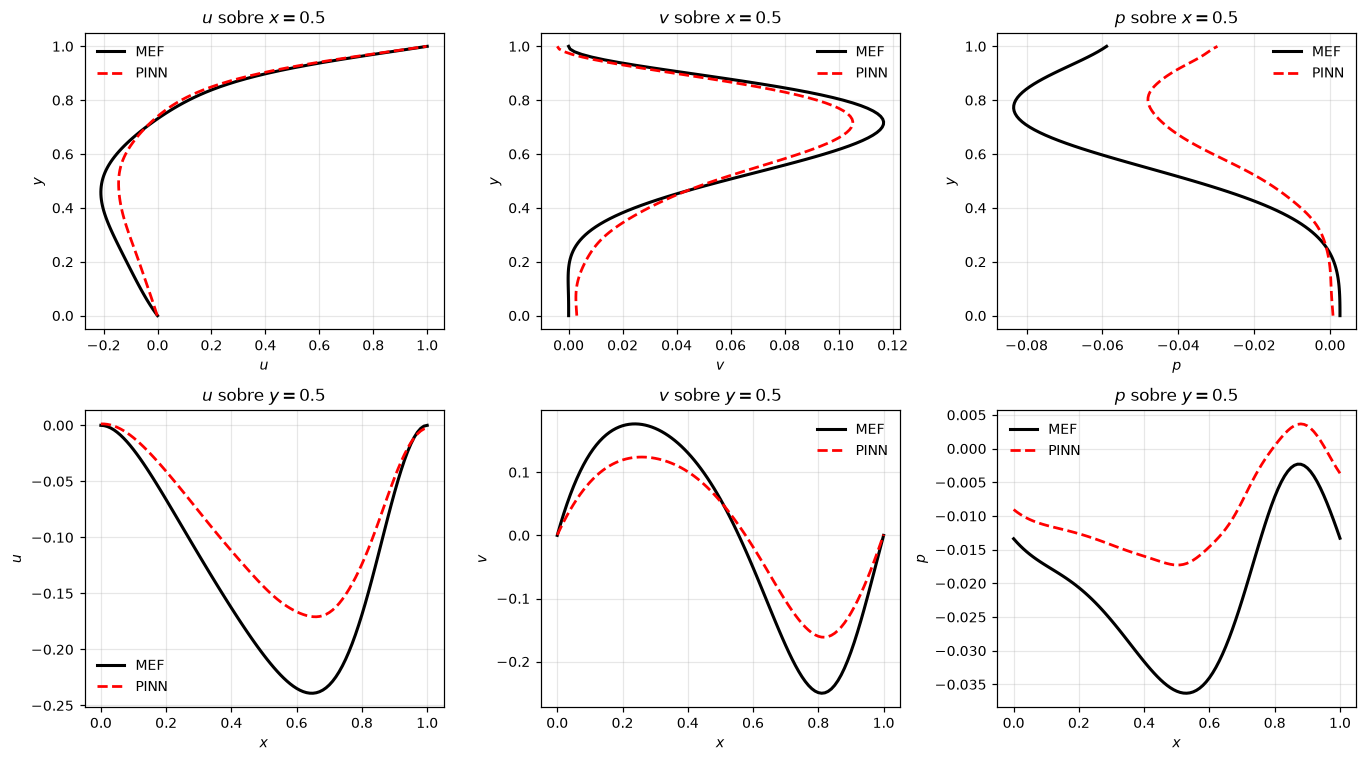

In [36]:
def profiles(P, grid, fname):
    """Perfiles de u, v y p sobre las rectas medias del dominio."""
    ix = int(np.argmin(np.abs(grid["x"] - 0.5)))
    iy = int(np.argmin(np.abs(grid["y"] - 0.5)))
    fig, axes = plt.subplots(2, 3, figsize=(12.5, 7))
    for col, k in enumerate(("u", "v", "p")):
        ax = axes[0, col]                                   # corte vertical x = 0.5
        ax.plot(grid[k][:, ix], grid["y"], "k-", lw=2, label="MEF")
        ax.plot(P[k][:, ix], grid["y"], "r--", lw=1.8, label="PINN")
        ax.set(xlabel=f"${k}$", ylabel="$y$", title=f"${k}$ sobre $x = 0.5$")
        ax.grid(alpha=0.3); ax.legend(frameon=False)

        ax = axes[1, col]                                   # corte horizontal y = 0.5
        ax.plot(grid["x"], grid[k][iy, :], "k-", lw=2, label="MEF")
        ax.plot(grid["x"], P[k][iy, :], "r--", lw=1.8, label="PINN")
        ax.set(xlabel="$x$", ylabel=f"${k}$", title=f"${k}$ sobre $y = 0.5$")
        ax.grid(alpha=0.3); ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(FIG_DIR / fname, bbox_inches="tight")
    plt.show()


profiles(P_base, grid, "06_perfiles.png")

---
# 5. ¿Alcanzan $N_{\rm pde}=1000$ y $N_{\rm bc}=100$? (consigna 6, segunda parte)

Para responderlo con evidencia y no por impresión, se entrena un segundo modelo **idéntico en todo** (misma
arquitectura, mismos pesos iniciales, mismo optimizador, mismas 20 000 épocas) salvo por la densidad de puntos de
colocación: $N_{\rm pde}=5000$ y $N_{\rm bc}=400$. La única variable que cambia es la que se quiere evaluar.

In [37]:
torch.manual_seed(SEED)
model_dense = PINN(LAYERS).to(DEVICE)
gen_dense = torch.Generator().manual_seed(SEED + 1)
ds_dense = to_device(build_collocation(n_pde=5000, n_bc=400, generator=gen_dense))

hist_dense = train(model_dense, ds_dense, tag="denso")

  época       total       L_pde        L_bc    L_anchor        lr     t[s]    it/s
      0  1.4271e+02  1.1822e+02  1.6527e+00  7.9667e+00  1.00e-03      0.0     nan
    500  1.5872e-01  2.9622e-02  1.2907e-02  2.3519e-05  1.00e-03      9.0    55.6
   1000  1.1770e-01  1.4723e-02  1.0297e-02  4.4625e-06  1.00e-03     17.8    56.7
   1500  9.7569e-02  1.1204e-02  8.6364e-03  1.4555e-06  1.00e-03     26.6    57.1
   2000  7.9942e-02  9.0710e-03  7.0870e-03  1.2416e-07  1.00e-03     35.3    57.2
   2500  6.7097e-02  7.6127e-03  5.9485e-03  1.7894e-08  1.00e-03     44.0    57.5
   3000  6.0485e-02  6.8177e-03  5.3668e-03  1.0015e-07  1.00e-03     52.7    57.5
   3500  5.6732e-02  6.3343e-03  5.0398e-03  1.0124e-09  1.00e-03     61.4    57.4
   4000  5.7671e-02  6.8705e-03  5.0796e-03  4.2845e-06  1.00e-03     70.1    57.5
   4500  5.4378e-02  6.7807e-03  4.7588e-03  9.4670e-06  1.00e-03     78.9    57.3
   5000  5.2082e-02  6.9116e-03  4.4884e-03  2.8630e-04  5.00e-04     87.6    57.2
   5

In [38]:
metrics_dense, metrics_dense_in, pred_dense = error_metrics(model_dense, ref, "modelo denso (5000/400)")

for title, mb, md in [("todos los nodos", metrics, metrics_dense),
                      ("excluyendo esquinas singulares", metrics_in, metrics_dense_in)]:
    print(f"\nError relativo — {title}\n")
    print(f"{'campo':<16} {'base (1000/100)':>18} {'denso (5000/400)':>19} {'mejora':>10}")
    print("-" * 66)
    for k in mb:
        print(f"{k:<16} {mb[k]['rel']:>17.2%} {md[k]['rel']:>18.2%} {mb[k]['rel'] / md[k]['rel']:>9.2f}x")

print(f"\n{'':<16} {'base':>18} {'denso':>19}")
print(f"{'pérdida final':<16} {hist['total'][-1]:>18.4e} {hist_dense['total'][-1]:>19.4e}")


Error sobre todos los nodos (20201) — modelo denso (5000/400)

campo                 ||e||_2   rel. ||e||/||f||         RMSE      |e|_max
--------------------------------------------------------------------------
u                  2.7340e+00             8.79%   1.9236e-02   5.3015e-01
v                  3.1500e+00            14.95%   2.2163e-02   2.3579e-01
p                  6.8784e+00            45.99%   4.8395e-02   4.2276e+00
p (sin offset)     6.8523e+00            46.30%   4.8212e-02   4.2318e+00

Error sobre excluyendo esquinas singulares, r < 0.05 (20116 nodos) — modelo denso (5000/400)

campo                 ||e||_2   rel. ||e||/||f||         RMSE      |e|_max
--------------------------------------------------------------------------
u                  2.3482e+00             7.62%   1.6556e-02   1.1229e-01
v                  3.0322e+00            14.46%   2.1379e-02   1.2652e-01
p                  1.2522e+00            14.30%   8.8287e-03   8.3837e-02
p (sin offset)     1.08

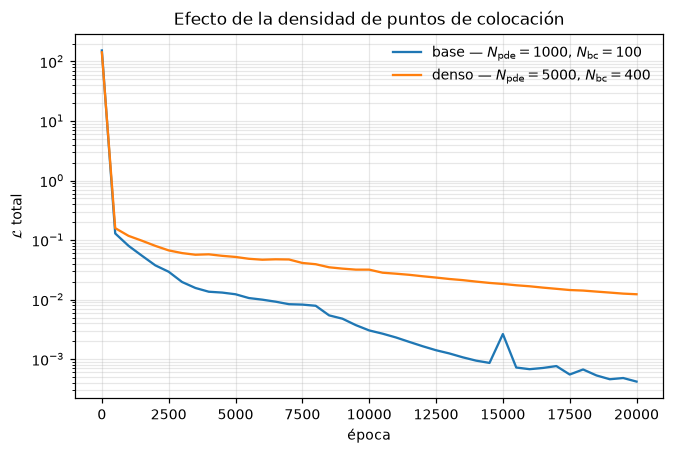

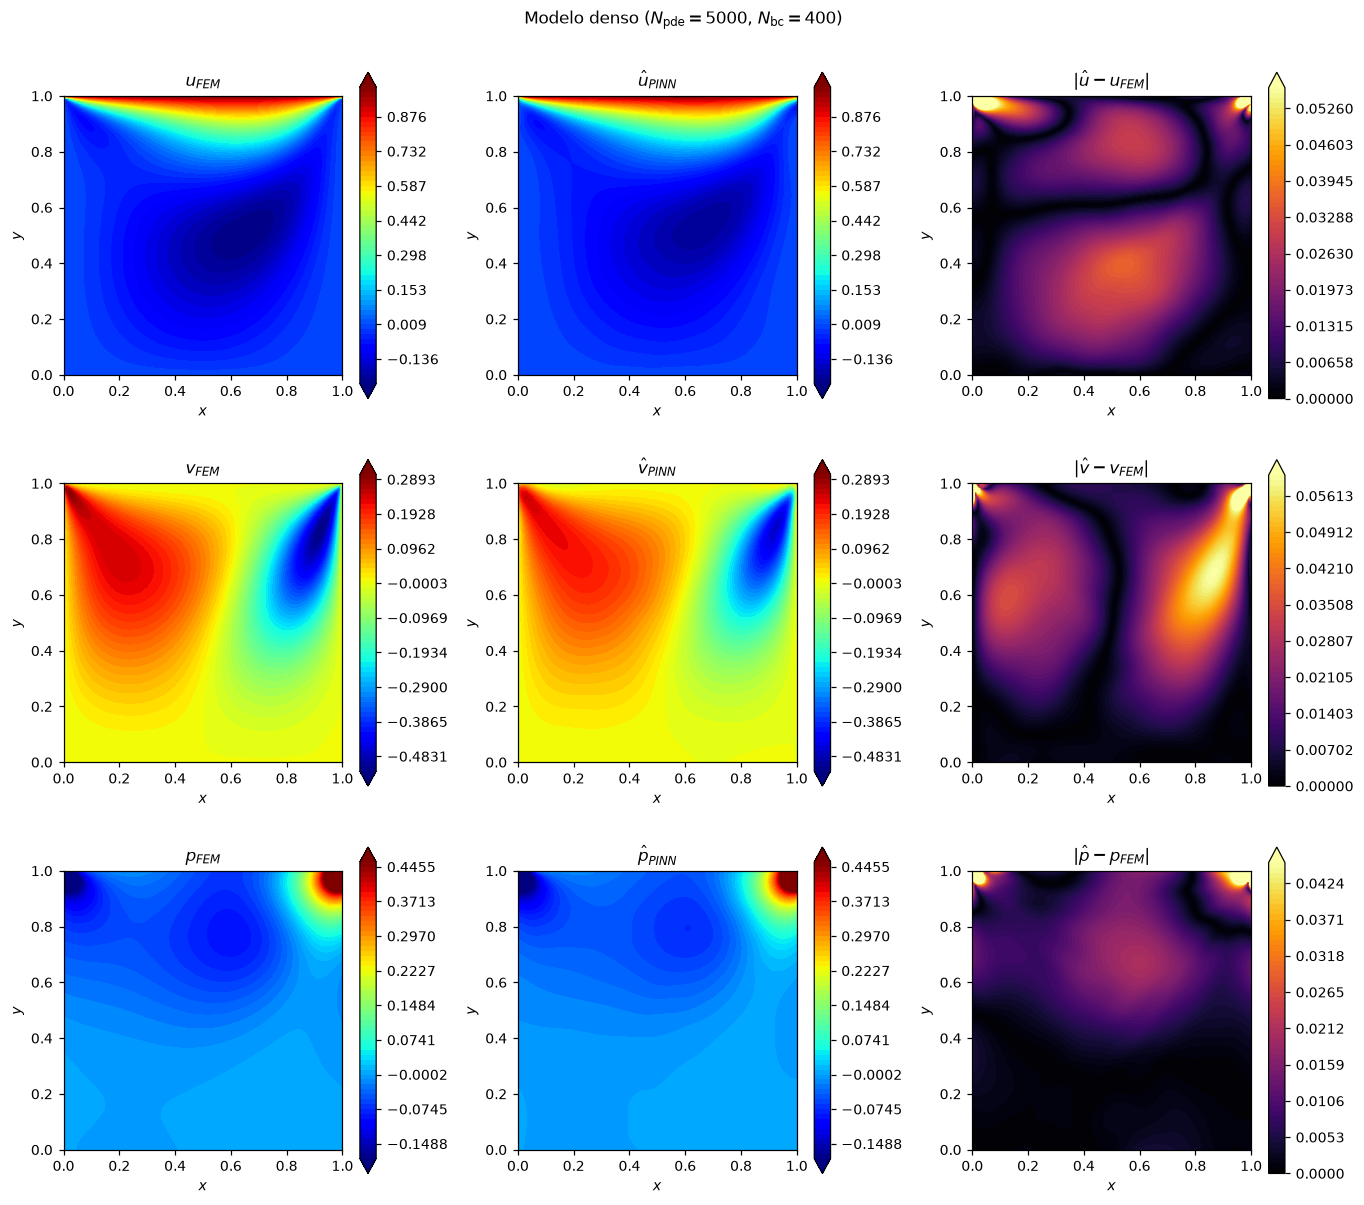

In [39]:
fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.semilogy(hist["epoch"], hist["total"], label=r"base — $N_{\rm pde}=1000$, $N_{\rm bc}=100$")
ax.semilogy(hist_dense["epoch"], hist_dense["total"], label=r"denso — $N_{\rm pde}=5000$, $N_{\rm bc}=400$")
ax.set(xlabel="época", ylabel=r"$\mathcal{L}$ total", title="Efecto de la densidad de puntos de colocación")
ax.legend(frameon=False); ax.grid(alpha=0.3, which="both")
fig.tight_layout()
fig.savefig(FIG_DIR / "07_densidad_puntos.png", bbox_inches="tight")
plt.show()

P_dense = field_comparison(model_dense, grid, "08_campos_error_denso.png",
                           "Modelo denso ($N_{\\rm pde}=5000$, $N_{\\rm bc}=400$)")

In [ ]:
summary = {
    "config": {"Re": RE, "layers": LAYERS, "epochs": EPOCHS, "lr": LR,
               "weights": WEIGHTS, "seed": SEED, "device": str(DEVICE)},
    "base": {"n_pde": N_PDE, "n_bc": N_BC, "loss_final": float(hist["total"][-1]),
             "errores_relativos": {k: float(v["rel"]) for k, v in metrics.items()},
             "errores_relativos_sin_esquinas": {k: float(v["rel"]) for k, v in metrics_in.items()}},
    "denso": {"n_pde": 5000, "n_bc": 400, "loss_final": float(hist_dense["total"][-1]),
              "errores_relativos": {k: float(v["rel"]) for k, v in metrics_dense.items()},
              "errores_relativos_sin_esquinas": {k: float(v["rel"]) for k, v in metrics_dense_in.items()}},
}
Path("resultados_tp1.json").write_text(json.dumps(summary, indent=2, ensure_ascii=False))
print(json.dumps(summary, indent=2, ensure_ascii=False))

{
  "config": {
    "Re": 100.0,
    "layers": [
      2,
      64,
      64,
      64,
      64,
      64,
      3
    ],
    "epochs": 20000,
    "lr": 0.001,
    "weights": {
      "pde": 1.0,
      "bc": 10.0,
      "anchor": 1.0
    },
    "seed": 1234,
    "device": "mps"
  },
  "base": {
    "n_pde": 1000,
    "n_bc": 100,
    "loss_final": 0.0004197741800453514,
    "errores_relativos": {
      "u": 0.21065673637347873,
      "v": 0.36147358065817753,
      "p": 0.6998267593217674,
      "p (sin offset)": 0.7015045917593379
    },
    "errores_relativos_sin_esquinas": {
      "u": 0.18150936115462546,
      "v": 0.34511874652053925,
      "p": 0.3662265232200003,
      "p (sin offset)": 0.3417217797305833
    }
  },
  "denso": {
    "n_pde": 5000,
    "n_bc": 400,
    "loss_final": 0.01230511162430048,
    "errores_relativos": {
      "u": 0.08789823961269994,
      "v": 0.14952595473030772,
      "p": 0.4599356345569523,
      "p (sin offset)": 0.4630416239260345
    },
    "e

---
# 6. Consigna 10 — Análisis crítico

> *En base al grado de convergencia obtenido durante el entrenamiento y los gráficos de error: ¿considera que el
> modelo es suficientemente "bueno"? ¿Qué fallas observa? ¿Qué aspectos positivos destaca? ¿Los hiperparámetros son
> adecuados? ¿Puede mejorarse el desempeño?*

*(Los valores numéricos citados a continuación corresponden a la corrida ejecutada en este notebook; ver las
tablas de las consignas 7 y 5.)*

## 6.1 ¿Es "bueno" el modelo?

**Como reconstrucción cualitativa, sí; como sustituto cuantitativo de un solver, no.** La distinción es la
conclusión central del trabajo.

Del lado positivo, el modelo recupera **sin ninguna supervisión** la topología correcta del flujo: el vórtice
primario descentrado hacia arriba y a la derecha, la capa límite bajo la tapa, el cambio de signo de $u$ en el
tercio inferior, los dos lóbulos de $v$ de signo opuesto a ambos lados de $x=0{,}5$. Los perfiles sobre $x=0{,}5$ e
$y=0{,}5$ reproducen la **forma** de las curvas MEF con fidelidad.

Del lado negativo, los números no acompañan a la impresión visual. El error relativo en norma-2 del modelo base es
de $\approx 21\%$ en $u$, $\approx 36\%$ en $v$ y $\approx 70\%$ en $p$ — muy lejos de lo que se le exigiría a un
método numérico. Los perfiles muestran de dónde sale: la red **subestima sistemáticamente la amplitud** de los
campos (el mínimo de $u$ sobre $y=0{,}5$ es $\approx-0{,}17$ contra $-0{,}24$ del MEF, un déficit del 30 %),
aunque acierte la forma. Es el patrón característico de una PINN sub-entrenada o sub-restringida: la red encuentra
una solución "suavizada", de menor energía, que satisface los residuos en los puntos donde se los evalúa pero no
alcanza los extremos del campo verdadero.

Conviene además desagregar el error, porque no todo es atribuible al modelo. La tabla que excluye un entorno de
radio $0{,}05$ alrededor de las dos esquinas superiores muestra qué parte del error viene de la **singularidad del
problema** —irrepresentable por cualquier red suave— y qué parte es error genuino del ajuste en el grueso del
dominio. En $p$ la diferencia entre ambas tablas es especialmente grande: el campo de referencia va de $-4{,}6$ a
$5{,}7$, pero ese rango lo fijan unos pocos nodos pegados a las esquinas, mientras el 99 % del dominio vive en
$|p|\lesssim 0{,}1$. El $70\%$ de error relativo en $p$ mide, sobre todo, que la red no reproduce dos picos que
tampoco tienen sentido físico acotado.

## 6.2 Fallas observadas

1. **Error concentrado en la tapa y en las esquinas superiores.** Es la falla dominante y se ve con claridad en los
   mapas de error absoluto. Tiene dos causas superpuestas: (i) la **singularidad de las esquinas**, donde la
   condición de borde es discontinua y la solución exacta no es suave — una red $\tanh$ no puede representar un
   salto, así que lo suaviza y comete allí su error máximo; y (ii) la **capa límite bajo la tapa**, donde el
   gradiente $\partial u/\partial y$ es máximo y el muestreo uniforme coloca pocos puntos.
2. **La presión es el campo peor resuelto.** Su error relativo es varias veces el de las velocidades. Es esperable
   y tiene tres motivos: la presión no está sujeta a ninguna condición de borde (sólo al anclaje puntual), sólo
   aparece en las ecuaciones a través de su gradiente —de modo que la información llega a la red de manera
   indirecta—, y hereda la singularidad logarítmica de las esquinas, que domina el rango del campo ($p$ va de
   $-4{,}6$ a $5{,}7$ concentrado en dos puntos, mientras el grueso del dominio vive cerca de cero). El
   diagnóstico "p sin offset" muestra cuánto del error es un simple desplazamiento constante mal calibrado y cuánto
   es error de forma.
3. **Sobreajuste a los puntos de colocación — la falla más instructiva.** El modelo base termina con una pérdida
   de $\approx 1{,}5\times10^{-3}$, **casi un orden de magnitud menor** que la del modelo denso
   ($\approx 1{,}2\times10^{-2}$), y sin embargo su error contra el *ground-truth* es **2 a 3 veces mayor** en los
   tres campos. (El factor exacto entre ambas pérdidas varía de corrida a corrida: el valor final es una muestra
   puntual de una serie ruidosa, mientras que los errores contra la referencia se mantienen estables.) La red
   aprendió a anular el residuo *en los 1000 puntos donde se lo mide* sin resolver la PDE en el resto del dominio:
   entre punto y punto interpola libremente. Dicho en los términos de la sección 1: minimizó una **realización
   particular** del estimador de Monte Carlo en vez de la integral que ese estimador aproxima. La consecuencia
   metodológica es fuerte: **el valor de $\mathcal{L}$ no es un estimador confiable de la calidad de la solución**
   cuando el conjunto de colocación es chico y fijo. Comparar pérdidas entre configuraciones con distinta densidad
   de puntos es directamente engañoso.
4. **Subestimación sistemática de la amplitud.** Visible en los seis perfiles: la red acierta la forma pero se
   queda corta en los extremos. Es consistente con el sesgo espectral de las redes con activación $\tanh$, que
   aprenden primero las componentes de baja frecuencia y baja amplitud.
5. **Estancamiento de la pérdida.** Las curvas muestran una caída rápida inicial seguida de una meseta larga con
   reducción lenta: es el comportamiento típico de Adam sobre un paisaje mal condicionado, y es la razón por la que
   aumentar simplemente el número de épocas rinde cada vez menos.
6. **Competencia entre términos.** El desagregado del residuo muestra que continuidad y cantidad de movimiento no
   convergen al mismo ritmo. Con pesos fijos no hay garantía de que el óptimo de la suma ponderada coincida con la
   solución física; el balance quedó fijado a mano.

## 6.3 Aspectos positivos

- **Cero datos de campo.** Toda la solución sale de las ecuaciones y las condiciones de borde: 1100 puntos y ninguna
  medición reproducen la topología completa del flujo. Es el argumento central a favor del enfoque.
- **Solución continua y diferenciable.** A diferencia del MEF, el modelo entrega $\hat u,\hat v,\hat p$ y sus
  derivadas en cualquier punto de $\Omega$, sin interpolación, con un costo de evaluación despreciable.
- **Sin malla.** Nunca se construyó una malla ni se resolvió un sistema lineal; el costo no depende de la geometría.
- **La divergencia se mantiene baja** en el interior, es decir, la incompresibilidad —la restricción más rígida del
  problema— se satisface razonablemente bien lejos de las paredes.

## 6.4 ¿Fueron adecuados los hiperparámetros?

| Hiperparámetro | Valor | Evaluación |
|---|---|---|
| Arquitectura | 5×64, $\tanh$ | Adecuada. La capacidad no es el cuello de botella: la pérdida se estanca por optimización, no por falta de expresividad. |
| $\lambda_{\rm bc}=10$ | fijo | Necesario (con $\lambda_{\rm bc}=1$ el entrenamiento coquetea con la solución trivial $\boldsymbol{u}\equiv0$), pero elegido a mano. Es el hiperparámetro más frágil del esquema. |
| Adam, lr $10^{-3}$ + decaimiento | — | Correcto para la fase inicial. Adam solo no alcanza para la fase final: el estancamiento pide un método de segundo orden. |
| 20 000 épocas | — | Suficientes, y en el modelo base probablemente **de más**: con 1000 puntos fijos, seguir bajando $\mathcal{L}$ es seguir sobreajustando. Más épocas sobre el mismo muestreo no reducen el error real. |
| $N_{\rm pde}=1000$, $N_{\rm bc}=100$ | — | **Insuficientes, y son el cuello de botella principal.** Ver 6.5. |

## 6.5 ¿Alcanzan $N_{\rm pde}=1000$ y $N_{\rm bc}=100$?

**No, claramente no.** El experimento controlado de la sección 5 (misma arquitectura, misma inicialización, mismas
épocas; la densidad es la única variable que cambia) reduce el error relativo **a menos de la mitad en los tres
campos** al pasar a 5000/400: $u$ de $\approx21\%$ a $\approx9\%$, $v$ de $\approx36\%$ a $\approx15\%$, $p$ de
$\approx70\%$ a $\approx46\%$. Y lo hace **empeorando** la pérdida de entrenamiento, lo que confirma el diagnóstico
de sobreajuste del punto 6.2.3. Dos lecturas:

- **Cobertura del interior.** 1000 puntos en $[0,1]^2$ equivalen a un espaciado medio de $\approx 0{,}03$ —contra
  $h=0{,}01$ de la malla MEF—, y siendo aleatorios dejan huecos bastante mayores. La PDE simplemente no se está
  imponiendo en regiones enteras del dominio, y en esos huecos la red interpola libremente.
- **Cobertura de la frontera.** 25 puntos por pared son un espaciado de $0{,}04$. Sobre la tapa, que es la que
  inyecta toda la energía del problema y donde la solución varía más rápido, esa resolución es la limitación más
  seria de todo el muestreo.

El matiz importante: **el error no baja proporcionalmente al número de puntos**. Multiplicar por 5 los puntos no
divide por 5 el error, y multiplica el costo por época. Esto indica que a partir de cierta densidad el factor
limitante deja de ser el muestreo y pasa a ser la optimización — lo cual orienta hacia dónde conviene invertir el
esfuerzo: no en más puntos uniformes, sino en **mejores** puntos y en mejor optimización.

### Qué dice la teoría de la cuadratura

Que el retorno sea decreciente no debería sorprender. Si los términos de la pérdida son estimadores de Monte Carlo
de las integrales del residuo, su error de cuadratura decae como

$$\delta Q_N \approx V\,\frac{\sigma_N}{\sqrt{N}}$$

es decir, **como $1/\sqrt{N}$, no como $1/N$**. Cuadruplicar los puntos reduce el error del estimador a la mitad.
Ésa es la razón de fondo por la cual densificar uniformemente el muestreo es una estrategia cara: para ganar un
orden de magnitud hacen falta cien veces más puntos, con el costo por época multiplicado en la misma proporción.

Es tentador leer los números en esa clave: al pasar de 1000 a 5000 puntos, $\sqrt{5}\approx2{,}24$, y los errores
relativos medidos mejoraron $2{,}40\times$ en $u$ y $2{,}43\times$ en $v$. **La coincidencia es sugerente pero no
debe tomarse como explicación causal**: la cota $1/\sqrt{N}$ acota el error con que se *estima la integral del
residuo*, que no es la misma cantidad que el error de la solución contra el *ground-truth*. Entre una y otra median
el error de optimización y el de aproximación de la red. Se registra como observación, no como ley.

Lo que sí se desprende con solidez es la dirección de la mejora: si el error del estimador escala con la varianza
$\sigma_N$ del integrando, conviene **reducir esa varianza** en lugar de aumentar $N$ a fuerza bruta. Eso es
exactamente lo que hacen el muestreo estratificado y el muestreo por importancia —concentrar puntos donde el
residuo es grande—, que en la literatura de PINNs aparecen como re-muestreo adaptativo (RAR).

## 6.6 Acciones de mejora

En orden de relación mejora/esfuerzo esperada:

1. **Re-muestreo periódico de los puntos de colocación** (sortear un conjunto nuevo cada $n$ épocas). Es la acción
   con mejor relación mejora/costo que sugiere la evidencia de este trabajo: ataca directamente el sobreajuste
   diagnosticado en 6.2.3 — la red deja de poder memorizar un conjunto fijo — **sin aumentar el costo por época**,
   a diferencia de subir la densidad. Equivale a imponer la PDE sobre un muestreo efectivamente infinito.
2. **Refinamiento con L-BFGS** tras la fase de Adam. Típicamente baja la pérdida uno o dos órdenes de magnitud
   adicionales, porque ataca el estancamiento de 6.2.5 usando información de curvatura. Advertencia derivada de
   6.2.3: sobre un conjunto de colocación chico y fijo, L-BFGS *profundiza el sobreajuste*; conviene aplicarlo
   junto con el re-muestreo, no en lugar de él.
3. **Muestreo no uniforme.** Densificar cerca de las paredes (muestreo estratificado o sesgado hacia la frontera)
   y, mejor aún, **re-muestreo adaptativo guiado por el residuo** (RAR): concentrar puntos donde $|r|$ es grande,
   que es justamente donde está el error. Ataca la falla 6.2.1 sin el costo de subir la densidad globalmente.
3. **Ponderación adaptativa de los términos** de la pérdida (`SA-PINN`, `NTK`, o balanceo por norma del gradiente),
   para eliminar el ajuste manual de $\lambda_{\rm bc}$ y evitar que un término domine a los demás.
4. **Imposición exacta de las condiciones de borde.** Escribir $\hat u = u_{\rm bc}(x,y) + B(x,y)\,\mathcal{N}(x,y)$
   con $B$ nula sobre la frontera elimina $\mathcal{L}_{\rm bc}$ de la pérdida: las condiciones pasan a cumplirse
   por construcción, desaparece el problema de ponderación y con él la solución trivial.
5. **Regularizar la singularidad de las esquinas**, por ejemplo suavizando el perfil de la tapa
   ($u(x,1)=1-\cosh(C(x-1/2))/\cosh(C/2)$, práctica habitual en la literatura de PINNs para esta cavidad), lo que
   vuelve el problema compatible con una red suave sin alterar el flujo lejos de las esquinas.
6. **Formulación en función de corriente.** Modelar $\psi$ y obtener $u=\partial_y\psi$, $v=-\partial_x\psi$
   satisface la continuidad **exactamente**, eliminando un término entero de la pérdida.
7. **Aprovechar los datos rotulados** de la consigna 3 como término adicional $\mathcal{L}_{\rm data}$: 10 puntos
   bien ubicados anclan la escala de la presión mucho mejor que el anclaje puntual y suelen acelerar sensiblemente
   la convergencia. Es el puente natural hacia el problema inverso.

---
# Anexo — Paisaje de la función de pérdida

Las notebooks de referencia de la cátedra (`heat_equation.ipynb`, `burgers_equation.ipynb`) cierran con una
visualización del *loss landscape*, que acá resulta especialmente pertinente: el diagnóstico de la sección 6.2.3
atribuye el estancamiento del entrenamiento a la optimización y no a la capacidad de la red, y esta figura permite
mirar directamente la geometría sobre la que Adam se está moviendo.

**Cómo se construye.** El espacio de parámetros tiene 17 027 dimensiones, así que sólo se lo puede mirar a través
de un corte 2D. Se toman dos direcciones aleatorias $\boldsymbol{d}_1, \boldsymbol{d}_2$ en ese espacio, se las
ortonormaliza por Gram-Schmidt y se evalúa la pérdida sobre la grilla

$$\theta(\alpha,\beta) = \theta_0 + \alpha\,\boldsymbol{d}_1 + \beta\,\boldsymbol{d}_2$$

con $\theta_0$ los parámetros del modelo ya entrenado. Las direcciones se escalan a una fracción de
$\|\theta_0\|$, de modo que $\alpha=1$ significa un desplazamiento del 5 % de la norma de los parámetros y la
figura es interpretable en términos relativos.

**Qué se puede leer y qué no.** Un corte aleatorio 2D de un espacio de 17 mil dimensiones es una muestra
sesgadamente optimista: casi cualquier dirección aleatoria en dimensión alta es aproximadamente ortogonal a las
pocas direcciones de curvatura patológica, de modo que el corte tiende a verse **más convexo y mejor condicionado
de lo que realmente es**. Sirve para verificar que $\theta_0$ está efectivamente en un mínimo local y para comparar
la escala de la pérdida alrededor de distintas soluciones; no sirve para afirmar que el problema de optimización
es fácil. Se lo incluye con esa salvedad.

In [41]:
def flatten_params(model):
    """Aplana todos los parametros entrenables en un unico vector."""
    return torch.cat([p.detach().flatten() for p in model.parameters()])


def set_params_from_vector(model, vec):
    """Escribe un vector plano de vuelta en los parametros del modelo (in-place)."""
    i = 0
    for p in model.parameters():
        n = p.numel()
        p.data.copy_(vec[i:i + n].view_as(p))
        i += n


def orthonormal_directions(model, seed=SEED):
    """Dos direcciones aleatorias ortonormales en el espacio de parametros (Gram-Schmidt)."""
    torch.manual_seed(seed)
    d1 = torch.cat([torch.randn_like(p).flatten() for p in model.parameters()])
    d1 = d1 / d1.norm()
    r = torch.cat([torch.randn_like(p).flatten() for p in model.parameters()])
    d2 = r - torch.dot(r, d1) * d1                      # Gram-Schmidt
    return d1, d2 / d2.norm()


def loss_landscape(model, ds, rel=0.05, steps=41):
    """Evalua la perdida total sobre un corte 2D del espacio de parametros.

    `rel` es la amplitud del barrido como fraccion de ||theta_0||. Los parametros
    del modelo se restauran siempre, incluso si la evaluacion falla.
    """
    bc_pack = pack_bc(ds)
    theta0 = flatten_params(model).clone()
    d1, d2 = orthonormal_directions(model)
    scale = rel * theta0.norm()
    grid = np.linspace(-1.0, 1.0, steps)
    Z = np.zeros((steps, steps))
    t0 = time.time()
    try:
        for i, a in enumerate(grid):
            for j, b in enumerate(grid):
                set_params_from_vector(model, theta0 + (a * d1 + b * d2) * scale)
                Z[j, i] = total_loss(compute_losses(model, ds, bc_pack))[0].item()
    finally:
        set_params_from_vector(model, theta0)           # restaurar siempre
    print(f"{steps}x{steps} evaluaciones en {time.time() - t0:.1f} s | "
          f"||theta_0|| = {theta0.norm():.2f} | barrido = ±{rel:.0%} de ||theta_0||")
    return grid, Z


grid_ll, Z_ll = loss_landscape(model, ds)

# Verificacion: el modelo entrenado debe quedar en el centro y ser el minimo del corte
centre = Z_ll[Z_ll.shape[0] // 2, Z_ll.shape[1] // 2]
print(f"pérdida en el centro (modelo entrenado): {centre:.4e}")
print(f"mínimo del corte                       : {Z_ll.min():.4e}")
print(f"máximo del corte                       : {Z_ll.max():.4e}  "
      f"({Z_ll.max() / centre:.0f}x el centro)")

41x41 evaluaciones en 9.1 s | ||theta_0|| = 27.39 | barrido = ±5% de ||theta_0||
pérdida en el centro (modelo entrenado): 4.1443e-04
mínimo del corte                       : 4.1443e-04
máximo del corte                       : 2.9321e+00  (7075x el centro)


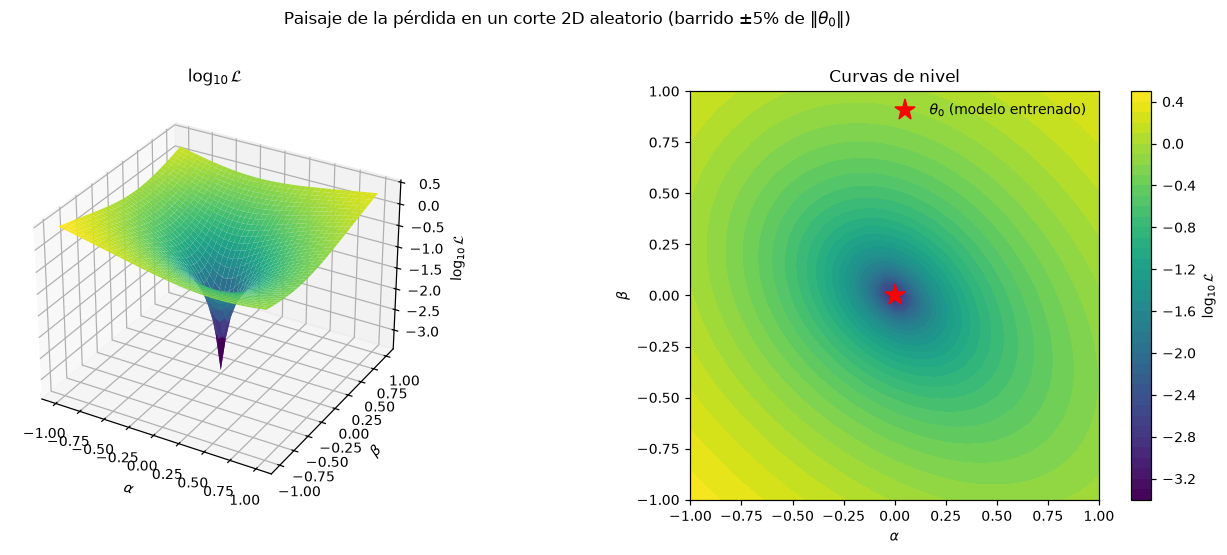

In [42]:
A, B = np.meshgrid(grid_ll, grid_ll)
fig = plt.figure(figsize=(12.5, 4.8))

ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot_surface(A, B, np.log10(Z_ll), cmap="viridis", linewidth=0, antialiased=True)
ax.set(xlabel=r"$\alpha$", ylabel=r"$\beta$", title=r"$\log_{10}\mathcal{L}$")
ax.set_zlabel(r"$\log_{10}\mathcal{L}$")

ax = fig.add_subplot(1, 2, 2)
im = ax.contourf(A, B, np.log10(Z_ll), levels=40, cmap="viridis")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\mathcal{L}$")
ax.plot(0, 0, "r*", markersize=14, label=r"$\theta_0$ (modelo entrenado)")
ax.set(xlabel=r"$\alpha$", ylabel=r"$\beta$", title="Curvas de nivel", aspect="equal")
ax.legend(frameon=False, loc="upper right")

fig.suptitle(r"Paisaje de la pérdida en un corte 2D aleatorio (barrido $\pm 5\%$ de $\|\theta_0\|$)", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "09_loss_landscape.png", bbox_inches="tight")
plt.show()

---
# Anexo B — ¿Está justificado el tamaño de la red?

La consigna pide **definir** la profundidad y el ancho de la red ("número de capas (profundidad), ancho (número
de neuronas por capa)"), sin prescribirlos. La elección de 5 capas × 64 neuronas de la sección 3 se justificó por
convención —es lo habitual en la literatura de PINNs para la cavidad— pero no se midió.

Conviene señalar que **las implementaciones de referencia de la cátedra usan redes bastante más angostas**:

| | Arquitectura |
|---|---|
| `heat_equation.ipynb` | 4 capas × 20 neuronas |
| `burgers_equation.ipynb` | 8 capas × 20 neuronas |
| Este TP | 5 capas × 64 neuronas |

La diferencia es defendible a priori —la cavidad tiene tres salidas acopladas por Navier-Stokes contra una sola en
Burgers y en el calor, y aquí no hay datos rotulados que guíen el ajuste— pero es una afirmación que hasta ahora
no se puso a prueba.

El análisis de la sección 6.4 aporta media respuesta: como la pérdida se estanca por optimización y no por falta
de expresividad, la red **no es demasiado chica**. Lo que nunca se verificó es lo contrario: si es **más grande de
lo necesario**. Si 4×40 diera el mismo error, se estaría pagando un costo de cómputo sin contrapartida.

**Experimento controlado.** Se entrenan cinco arquitecturas variando *únicamente* profundidad y ancho: mismo
muestreo (los mismos 1100 puntos), misma semilla de inicialización, mismos pesos de la pérdida, mismo optimizador
y las mismas 20 000 épocas. La fila de 5×64 funciona como **control**: debe reproducir el error reportado en la
consigna 7.

> Esta celda entrena cinco modelos desde cero: unos 20 minutos. La configuración de 6×128 es la más lenta.

**Alcance de la conclusión.** El resultado vale para *este* régimen: 1000 puntos de colocación y 20 000 épocas.
Con un orden de magnitud más de puntos —como en el TP2— la cantidad de información a ajustar crece y el
requerimiento de capacidad puede cambiar. No es una respuesta universal sobre el tamaño de red.

In [16]:
ARCHS = [
    (4, 20, "cátedra — heat_equation"),
    (8, 20, "cátedra — burgers_equation"),
    (4, 40, ""),
    (5, 64, "← usada en este TP"),
    (6, 128, ""),
]


def arch_errors(model):
    """Error relativo en norma-2 por campo, con y sin las esquinas singulares."""
    pred = dict(zip(("u", "v", "p"), predict(model, ref["x"], ref["y"])))
    m = away_from_corners(ref)
    out = {}
    for k in ("u", "v", "p"):
        e = pred[k] - ref[k]
        out[k] = _stats(e, ref[k])["rel"]
        out[k + "_in"] = _stats(e[m], ref[k][m])["rel"]
    return out


arch_results = []
ds = to_device(collocation)
for depth, width, note in ARCHS:
    torch.manual_seed(SEED)                       # misma inicialización para todas
    m = PINN([2] + [width] * depth + [3]).to(DEVICE)
    n_par = sum(p.numel() for p in m.parameters())
    print(f"\n=== {depth} capas x {width} neuronas ({n_par:,} parámetros) {note} ===")
    t0 = time.time()
    h = train(m, ds, log_every=5_000, tag=f"{depth}x{width}")
    arch_results.append({"depth": depth, "width": width, "note": note, "params": n_par,
                         "loss": float(h["total"][-1]), "t": time.time() - t0,
                         **arch_errors(m)})


=== 4 capas x 20 neuronas (1,383 parámetros) cátedra — heat_equation ===
  época       total       L_pde        L_bc    L_anchor        lr     t[s]    it/s
      0  1.4238e+02  1.1995e+02  2.1719e+00  7.0252e-01  1.00e-03      0.0     nan
   5000  2.8477e-02  7.6941e-03  2.0783e-03  1.4256e-07  5.00e-04     45.3   110.3
  10000  1.7373e-02  5.5840e-03  1.1789e-03  4.2520e-09  2.50e-04     91.0   109.5
  15000  1.3394e-02  5.1981e-03  8.1961e-04  4.7558e-09  1.25e-04    136.9   108.8
  20000  1.1469e-02  4.6305e-03  6.8380e-04  6.8937e-10  6.25e-05    182.8   109.1

entrenamiento 4x20 finalizado en 182.8 s

=== 8 capas x 20 neuronas (3,063 parámetros) cátedra — burgers_equation ===
  época       total       L_pde        L_bc    L_anchor        lr     t[s]    it/s
      0  2.6273e+02  2.5348e+02  6.4886e-01  2.7681e+00  1.00e-03      0.0     nan
   5000  2.2441e-02  9.7546e-03  1.2686e-03  2.3052e-08  5.00e-04     85.1    58.8
  10000  2.8104e-02  1.4441e-02  1.3410e-03  2.5387e-04  2.5

In [17]:
print(f"\n{'arquitectura':<14} {'params':>8} {'L final':>11} {'rel u':>8} {'rel v':>8} "
      f"{'rel p':>8} {'rel u*':>8} {'rel p*':>8} {'t [min]':>9}")
print("-" * 92)
for r in arch_results:
    name = f"{r['depth']}x{r['width']}"
    print(f"{name:<14} {r['params']:>8,} {r['loss']:>11.3e} {r['u']:>7.2%} {r['v']:>7.2%} "
          f"{r['p']:>7.2%} {r['u_in']:>7.2%} {r['p_in']:>7.2%} {r['t'] / 60:>9.1f}   {r['note']}")
print("\n* excluyendo las esquinas singulares")


arquitectura     params     L final    rel u    rel v    rel p   rel u*   rel p*   t [min]
--------------------------------------------------------------------------------------------
4x20              1,383   1.147e-02  42.61%  87.85%  89.15%  40.95%  78.65%       3.0   cátedra — heat_equation
8x20              3,063   8.716e-03  39.27%  76.38%  86.44%  37.47%  69.37%       5.7   cátedra — burgers_equation
4x40              5,163   1.794e-03  24.13%  44.75%  74.79%  21.69%  45.81%       3.3   
5x64             17,027   4.198e-04  21.07%  36.15%  69.98%  18.15%  36.62%       4.1   ← usada en este TP
6x128            83,331   3.230e-04  21.30%  36.35%  69.99%  18.31%  36.68%       4.9   

* excluyendo las esquinas singulares


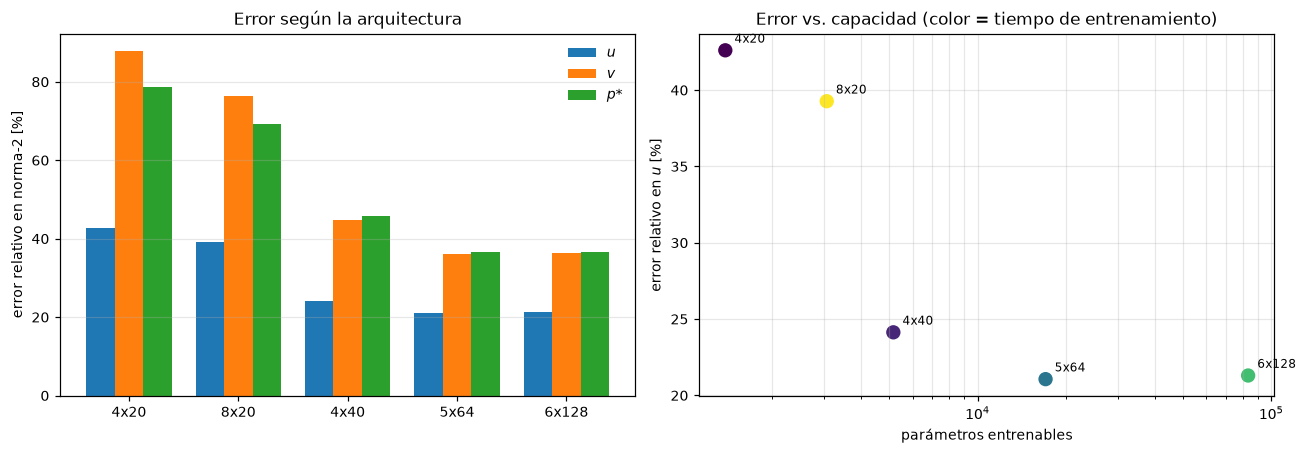

In [18]:
labels = [f"{r['depth']}x{r['width']}" for r in arch_results]
xpos = np.arange(len(labels))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
for i, (f, lbl) in enumerate([("u", "$u$"), ("v", "$v$"), ("p (sin esq.)", "$p$*")]):
    key = "p_in" if f.startswith("p") else f
    ax.bar(xpos + (i - 1) * 0.26, [r[key] * 100 for r in arch_results], width=0.26, label=lbl)
ax.set(ylabel="error relativo en norma-2 [%]", title="Error según la arquitectura")
ax.set_xticks(xpos); ax.set_xticklabels(labels); ax.legend(frameon=False)
ax.grid(alpha=0.3, axis="y")

ax = axes[1]
ax.scatter([r["params"] for r in arch_results], [r["u"] * 100 for r in arch_results],
           s=70, c=[r["t"] for r in arch_results], cmap="viridis")
for r, lbl in zip(arch_results, labels):
    ax.annotate(lbl, (r["params"], r["u"] * 100), textcoords="offset points",
                xytext=(6, 5), fontsize=8)
ax.set(xscale="log", xlabel="parámetros entrenables", ylabel="error relativo en $u$ [%]",
       title="Error vs. capacidad (color = tiempo de entrenamiento)")
ax.grid(alpha=0.3, which="both")

fig.tight_layout()
fig.savefig(FIG_DIR / "10_arquitectura.png", bbox_inches="tight")
plt.show()

## Conclusiones del estudio de arquitectura

*(Valores de la corrida de referencia; la tabla y la figura de arriba muestran los de esta ejecución.)*

| Arquitectura | Params | $\mathcal{L}$ final | rel $u$ | rel $v$ | rel $p$ | rel $u$ sin esq. | $t$ |
|---|---|---|---|---|---|---|---|
| 4×20 *(cátedra, heat)* | 1 383 | 1,147e-2 | 42,61 % | 87,85 % | 89,15 % | 40,95 % | 3,0 min |
| 8×20 *(cátedra, burgers)* | 3 063 | 8,716e-3 | 39,27 % | 76,38 % | 86,44 % | 37,47 % | 5,7 min |
| 4×40 | 5 163 | 1,794e-3 | 24,13 % | 44,75 % | 74,79 % | 21,69 % | 3,3 min |
| **5×64** *(la usada)* | 17 027 | 4,198e-4 | **21,07 %** | **36,15 %** | **69,98 %** | 18,15 % | 4,1 min |
| 6×128 | 83 331 | 3,230e-4 | 21,30 % | 36,35 % | 69,99 % | 18,31 % | 4,9 min |

**El control es consistente.** La fila de 5×64 reproduce los valores de la consigna 7 ($21{,}08\%$, $36{,}18\%$,
$70{,}00\%$) en todas sus cifras significativas —es el mismo modelo, con la misma semilla y el mismo muestreo—,
lo que confirma que la comparación es válida y que las diferencias entre filas son atribuibles únicamente a la
arquitectura.

### 1. Las arquitecturas de la cátedra son insuficientes para este problema

Con 20 neuronas de ancho el error en $u$ sube a $39$–$43\%$ y en $v$ llega a $88\%$: no es un deterioro marginal
sino la diferencia entre reconstruir el flujo y no reconstruirlo. Esto **valida empíricamente** la divergencia
respecto de `heat_equation.ipynb` y `burgers_equation.ipynb`, que hasta ahora se justificaba sólo con el argumento
cualitativo de que la cavidad es un problema más duro (tres campos acoplados por Navier-Stokes en vez de uno, y
sin datos rotulados que guíen el ajuste). El argumento era correcto, pero ahora está medido.

### 2. 5×64 está en el codo de la curva

Es la arquitectura **más chica que alcanza la meseta**: 6×128 tiene casi cinco veces más parámetros y no mejora
nada — de hecho queda marginalmente peor en los tres campos ($21{,}30\%$ contra $21{,}07\%$ en $u$), diferencia
que está dentro del ruido entre corridas. Hacia abajo, en cambio, el costo es real: 4×40 pierde tres puntos en
$u$ y casi nueve en $v$. La elección estaba bien hecha, aunque por convención y no por medición.

### 3. Confirma por otra vía el diagnóstico de la sección 6.4

Éste es el resultado más interesante, y conviene leerlo con cuidado. **6×128 alcanza una pérdida de entrenamiento
menor que 5×64** ($3{,}23\times10^{-4}$ contra $4{,}20\times10^{-4}$) y sin embargo su error contra el
*ground-truth* es **levemente peor** en los tres campos. Con casi cinco veces más parámetros, la capacidad
adicional se gasta en ajustar mejor el residuo *en los 1000 puntos de colocación* sin mejorar la solución en el
resto del dominio.

Es la misma disociación entre pérdida y calidad diagnosticada en la sección 6.2.3, ahora por la vía de la
capacidad en lugar de la densidad de puntos, y permite cerrar la pregunta que 6.4 dejaba abierta: **la
expresividad de la red no es el factor limitante**. Si lo fuera, quintuplicar los parámetros tendría que mejorar
la solución; lo único que mejora es el ajuste al conjunto de colocación.

> **Advertencia metodológica.** Una versión anterior de este análisis apoyaba esta conclusión en el orden inverso
> de las pérdidas finales, observado en otra corrida. Ese orden **se invierte entre ejecuciones**: la pérdida
> final es una muestra puntual de una serie ruidosa. El error contra el *ground-truth*, en cambio, se mantiene
> estable en todas las corridas. Es la misma lección de 6.2.3 aplicada a este anexo: **conviene no construir
> argumentos sobre el valor final de $\mathcal{L}$.**

### 4. El costo lo domina la profundidad, no el ancho

Dato lateral con consecuencias prácticas: **8×20 (3063 parámetros) tardó 5,7 min, más que 6×128 (83 331
parámetros), que tardó 4,9 min** — 27 veces más parámetros y aun así más rápido. En términos de velocidad de
iteración, 8×20 corre a 58,6 it/s contra 82 it/s de 5×64, que es una red bastante más grande.

La razón es que cada capa agrega una **dependencia secuencial** al grafo de autodiferenciación —y el residuo lo
recorre varias veces, por las derivadas segundas—, un costo que no se paraleliza. Ensanchar, en cambio, agranda
las matrices de cada capa, que es justamente lo que la GPU hace bien. **Ante la necesidad de recortar tiempo
conviene sacrificar profundidad antes que ancho**, al revés de lo que sugiere la intuición de contar parámetros.

### Alcance

Las conclusiones valen para este régimen: 1000 puntos de colocación y 20 000 épocas. Con un orden de magnitud más
de puntos —el caso del TP2— hay más información que ajustar y el requerimiento de capacidad podría desplazarse.
Lo que sí se transfiere es el punto 3: si el límite es la optimización y no la capacidad, agrandar la red no es
el camino de mejora. Las acciones propuestas en 6.6 (L-BFGS, muestreo adaptativo, ponderación adaptativa) atacan
el factor correcto.